# 조선 기자재 선후행 & 거리 기반 페어트레이딩
- **Part I**: 대형 조선사 → 기자재 선행 (Hou 2007 방식)
- **Part J**: 거리 기반 페어트레이딩 (Gatev, Goetzmann & Rouwenhorst 2006 방식)

기존 노트북과 결과 파일은 건드리지 않으며, 결과는 `results/leadlag_pairs/`에 저장합니다.
주가는 기존과 같은 네이버 수정주가(pykrx `adjusted=True`)를 씁니다.

---
## Step 0. 기자재 유니버스 확정 (수익률은 보지 않음)
포함 기준 (미리 정한 값, 바꾸지 않음)
1. 2021년 9월 이전부터 데이터가 있을 것 (5년 이상)
2. 일평균 거래대금 중앙값 5억원 이상
3. 종목코드 기준으로 동일 회사 이력이 이어질 것

**거래대금 산출**: 수정주가는 분할·증자 때 과거 가격을 소급 조정하므로 쓰지 않음.
pykrx 거래대금 컬럼은 KRX 원천이라 현재 로그인이 필요해 수신 불가 →
**네이버 모바일 시세 API의 수정 전 종가 × 수정 전 거래량**으로 계산 (삼성전자 2018-05-04 50:1 분할 전 종가 2,650,000원으로 수정 전 값임을 확인).

In [1]:
import os, time, re, warnings
import numpy as np
import pandas as pd
import requests
warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.max_colwidth", 90); pd.set_option("display.width", 220)

RES_DIR = os.path.join("results", "leadlag_pairs"); os.makedirs(RES_DIR, exist_ok=True)
START = "2015-01-01"
END   = pd.Timestamp.today().strftime("%Y-%m-%d")
DART_API_KEY = os.environ["DART_API_KEY"]          # 환경변수에서 읽음 (키를 노트북·출력에 남기지 않음)
assert DART_API_KEY.strip(), "환경변수 DART_API_KEY가 비어 있습니다"

# 후보 (SOL 조선기자재 ETF 편입종목 기준). HD현대마린솔루션은 사후 서비스·최근 상장으로 사전 제외
CAND = {
    "017960": ("한국카본", "보냉재"),       "033500": ("동성화인텍", "보냉재"),
    "075580": ("세진중공업", "탱크·구조물"), "014620": ("성광벤드", "피팅·밸브"),
    "023160": ("태광", "피팅·밸브"),         "082740": ("한화엔진", "엔진"),
    "071970": ("HD현대마린엔진", "엔진"),    "077970": ("STX엔진", "엔진"),
    "460930": ("현대힘스", "블록·크레인"),
}
# 포함 기준 (미리 정한 값 — 바꾸지 않음)
MIN_START = pd.Timestamp("2021-09-01")   # 이 날짜 이전부터 데이터
MIN_TV    = 5e8                          # 일평균 거래대금 중앙값 5억원
NEAR      = (3e8, 8e8)                   # 기준 근처 표시 구간 (3억~8억원)

In [2]:
# ---- Step 0-1. DART: 시장·설립일·현재 사명, 이력 공시 ----
import OpenDartReader
dart = OpenDartReader(DART_API_KEY)
_redact = lambda s: str(s).replace(DART_API_KEY, "***")
MKT = {"Y": "코스피", "K": "코스닥", "N": "코넥스", "E": "기타"}
PAT  = r"상호|최대주주변경|합병|분할|영업양수|영업양도|감자|주식병합|회생|상장폐지|관리종목|매매거래정지"
EXCL = r"정정|첨부|자회사|종속회사|\[기재|해지|담보|질권|계획서|주요사항보고서\(자기|투자판단|출자법인"
info_rows, hist = [], []
for c, (nm, grp) in CAND.items():
    ci = dart.company(c)
    info_rows.append({"code": c, "name": nm, "group": grp, "DART 사명": ci.get("corp_name"),
                      "고유번호": ci.get("corp_code"), "시장": MKT.get(ci.get("corp_cls"), ci.get("corp_cls")),
                      "설립일": ci.get("est_dt")})
    try:
        df = dart.list(c, start="1999-01-01", kind="", final=False)
        n = df["report_nm"].astype(str)
        h = df[n.str.contains(PAT) & ~n.str.contains(EXCL)][["rcept_dt", "report_nm", "rcept_no"]].assign(code=c, name=nm)
        hist.append(h)
    except Exception as ex:
        print(f"  DART 실패({c}): {_redact(ex)}")
    time.sleep(0.3)
info = pd.DataFrame(info_rows).set_index("code")
hist = pd.concat(hist, ignore_index=True).sort_values(["code", "rcept_dt"])
hist.to_csv(f"{RES_DIR}/S0_dart_history.csv", index=False, encoding="utf-8-sig")
display(info)
print("분석 기간(2015~) 중 이력 공시 건수:")
display(hist[hist["rcept_dt"] >= "20150101"].groupby("name").size().rename("건수").to_frame())

,name,group,DART 사명,고유번호,시장,설립일
code,,,,,,
017960,한국카본,보냉재,(주)한국카본,00159795,코스피,19840917
033500,동성화인텍,보냉재,(주)동성화인텍,00231105,코스닥,19850731
075580,세진중공업,탱크·구조물,(주)세진중공업,00415628,코스피,19990920
014620,성광벤드,피팅·밸브,(주)성광벤드,00132318,코스닥,19800223
023160,태광,피팅·밸브,(주)태광,00153375,코스닥,19820901
082740,한화엔진,엔진,한화엔진(주),00361008,코스피,19991230
071970,HD현대마린엔진,엔진,에이치디현대마린엔진(주),00406046,코스피,20010615
077970,STX엔진,엔진,STX엔진(주),00480455,코스피,20040401
460930,현대힘스,블록·크레인,현대힘스 주식회사,00667373,코스닥,20080425


분석 기간(2015~) 중 이력 공시 건수:


,건수
name,
HD현대마린엔진,41
STX엔진,7
동성화인텍,8
세진중공업,6
한국카본,10
한화엔진,12
현대힘스,4


In [3]:
# ---- Step 0-2. 네이버 수정주가(기존 방식): 첫 거래일, 데이터 시작일, 결측·거래정지 ----
from pykrx import stock
import FinanceDataReader as fdr
cal = fdr.DataReader("KS11", START, END).index                  # 거래일 달력 (기존과 동일 원천)
cov_rows, halts = [], []
for c, (nm, grp) in CAND.items():
    full = stock.get_market_ohlcv("19900101", END.replace("-", ""), c)   # adjusted=True → 네이버 수정주가
    full.index = pd.to_datetime(full.index)
    d = full.loc[START:]
    v = d["거래량"]
    live = cal[(cal >= d.index.min()) & (cal <= min(d.index.max(), cal.max()))]
    z = (v == 0); g = (z != z.shift()).cumsum()
    runs = [(s.index[0].date(), s.index[-1].date(), len(s)) for _, s in z.groupby(g) if s.iloc[0] and len(s) >= 5]
    for r in runs: halts.append({"code": c, "name": nm, "from": r[0], "to": r[1], "days": r[2]})
    cov_rows.append({"code": c, "네이버 수정주가 최초일(원천 한계)": full.index.min().date(), "분석용 데이터 시작일": d.index.min().date(),
                     "마지막 거래일": d.index.max().date(), "관측일": len(d),
                     "달력 대비 빠진 날": int(len(live.difference(d.index))),
                     "거래량 0인 날": int(z.sum()), "5일 이상 정지 구간": len(runs)})
    time.sleep(0.3)
cov = pd.DataFrame(cov_rows).set_index("code")
display(cov)
halts = pd.DataFrame(halts); print("5거래일 이상 거래량 0(거래정지) 구간:"); display(halts)
halts.to_csv(f"{RES_DIR}/S0_halts.csv", index=False, encoding="utf-8-sig")

KRX 로그인 실패: KRX_ID 또는 KRX_PW 환경 변수가 설정되지 않았습니다.


,네이버 수정주가 최초일(원천 한계),분석용 데이터 시작일,마지막 거래일,관측일,달력 대비 빠진 날,거래량 0인 날,5일 이상 정지 구간
code,,,,,,,
017960,2014-07-08,2015-01-02,2026-09-29,2881,0,0,0
033500,2014-07-08,2015-01-02,2026-09-29,2881,0,13,1
075580,2015-11-30,2015-11-30,2026-09-29,2655,0,0,0
014620,2014-07-08,2015-01-02,2026-09-29,2881,0,0,0
023160,2014-07-08,2015-01-02,2026-09-29,2881,0,0,0
082740,2014-07-08,2015-01-02,2026-09-29,2881,0,10,1
071970,2014-07-08,2015-01-02,2026-09-29,2881,0,204,4
077970,2014-07-08,2015-01-02,2026-09-29,2881,0,84,1
460930,2024-01-26,2024-01-26,2026-09-29,649,0,0,0


5거래일 이상 거래량 0(거래정지) 구간:


,code,name,from,to,days
0,033500,동성화인텍,2025-10-30,2025-11-17,13
1,082740,한화엔진,2018-06-01,2018-06-18,10
2,071970,HD현대마린엔진,2015-01-02,2015-05-06,84
3,071970,HD현대마린엔진,2016-07-25,2016-08-01,6
4,071970,HD현대마린엔진,2017-01-17,2017-05-24,85
5,071970,HD현대마린엔진,2018-11-19,2018-12-26,27
6,077970,STX엔진,2015-01-02,2015-05-06,84


In [4]:
# ---- Step 0-3. 거래대금: 네이버 모바일 시세 API의 수정 전 종가 × 수정 전 거래량 ----
HDR = {"User-Agent": "Mozilla/5.0"}
def naver_raw_daily(code, start=START, page_size=60, max_pages=400):
    rows = []
    for page in range(1, max_pages + 1):
        r = requests.get(f"https://m.stock.naver.com/api/stock/{code}/price",
                         params={"pageSize": page_size, "page": page}, headers=HDR, timeout=20)
        js = r.json()
        if not isinstance(js, list) or not js: break
        rows += js
        if js[-1]["localTradedAt"] < start: break
        time.sleep(0.12)
    df = pd.DataFrame(rows)
    df["date"] = pd.to_datetime(df["localTradedAt"])
    df["close_raw"] = df["closePrice"].str.replace(",", "").astype(float)
    df["vol_raw"] = df["accumulatedTradingVolume"].astype(float)
    for k in ["open", "high", "low"]:
        df[f"{k}_raw"] = df[f"{k}Price"].astype(str).str.replace(",", "").astype(float)
    return df.set_index("date").sort_index().loc[start:, ["open_raw", "high_raw", "low_raw", "close_raw", "vol_raw"]]

tv_rows, RAW = [], {}
for c, (nm, grp) in CAND.items():
    raw = naver_raw_daily(c); RAW[c] = raw
    t = raw.loc[raw["vol_raw"] > 0]
    tv = t["close_raw"] * t["vol_raw"]
    yearly = tv.groupby(tv.index.year).median()
    # 참고: 수정주가 기준으로 계산했다면 (쓰지 않음, 차이 확인용)
    adj = stock.get_market_ohlcv(START.replace("-", ""), END.replace("-", ""), c)["종가"]
    adj.index = pd.to_datetime(adj.index)
    fac = (raw["close_raw"] / adj.reindex(raw.index)).dropna()
    steps = int((fac.pct_change().abs() > 0.01).sum())
    tv_adj = (adj.reindex(t.index) * t["vol_raw"]).median()
    tv_typ = (t[["open_raw", "high_raw", "low_raw", "close_raw"]].mean(axis=1) * t["vol_raw"]).median()
    tv_rows.append({"code": c, "거래대금 산출 방식": "네이버 모바일 API 수정 전 종가×거래량",
                    "산출 기간": f"{tv.index.min().date()}~{tv.index.max().date()}", "산출일수": len(tv),
                    "거래대금 중앙값(억원)": tv.median() / 1e8,
                    "연도별 중앙값 최저(억원)": yearly.min() / 1e8, "최저 연도": int(yearly.idxmin()),
                    "수정 계수 변화 횟수(2015~)": steps,
                    "(참고) 수정 전 평균가(OHLC/4)×거래량 중앙값(억원)": tv_typ / 1e8,
                    "(참고, 쓰지 않음) 수정주가×거래량 중앙값(억원)": tv_adj / 1e8})
    time.sleep(0.3)
tv = pd.DataFrame(tv_rows).set_index("code")
display(tv)

,거래대금 산출 방식,산출 기간,산출일수,거래대금 중앙값(억원),연도별 중앙값 최저(억원),최저 연도,수정 계수 변화 횟수(2015~),(참고) 수정 전 평균가(OHLC/4)×거래량 중앙값(억원),"(참고, 쓰지 않음) 수정주가×거래량 중앙값(억원)"
code,,,,,,,,,
017960,네이버 모바일 API 수정 전 종가×거래량,2015-01-02~2026-09-29,2881,33.77,8.65,2017,0,33.59,33.77
033500,네이버 모바일 API 수정 전 종가×거래량,2015-01-02~2026-09-29,2868,19.86,6.12,2016,0,19.98,19.86
075580,네이버 모바일 API 수정 전 종가×거래량,2015-11-30~2026-09-29,2655,12.74,2.01,2015,1,12.78,11.34
014620,네이버 모바일 API 수정 전 종가×거래량,2015-01-02~2026-09-29,2881,21.88,9.33,2019,0,22.04,21.88
023160,네이버 모바일 API 수정 전 종가×거래량,2015-01-02~2026-09-29,2881,15.20,4.04,2016,0,15.26,15.20
082740,네이버 모바일 API 수정 전 종가×거래량,2015-01-02~2026-09-29,2871,31.76,6.24,2019,3,31.74,24.06
071970,네이버 모바일 API 수정 전 종가×거래량,2015-05-07~2026-09-29,2677,16.22,0.61,2015,5,16.36,42.35
077970,네이버 모바일 API 수정 전 종가×거래량,2015-05-07~2026-09-29,2797,5.05,1.14,2019,2,5.08,5.05
460930,네이버 모바일 API 수정 전 종가×거래량,2024-01-26~2026-09-29,649,51.88,39.21,2026,0,52.08,51.88


In [5]:
# ---- Step 0-4. 동일 회사 이력 판단 (DART 공시·언론 확인 근거) ----
# 판정 기준: 같은 법인(DART 고유번호·설립일 동일)이 종목코드를 계속 유지했는지, 우회상장·코드 재사용이 없는지.
# 분석 기간(2015~) 중 사업 구성의 큰 변화는 '주의'로 따로 적음.
LINEAGE = {
 "017960": ("이어짐", "", "상호·코드 변경 없음. 2023-10 계열사 한국신소재(유리섬유) 흡수합병(존속 한국카본). 2026-08 100% 자회사 4곳 소규모합병 결정, 2026-03 자기주식 소각", "20230912000162, 20260814002868"),
 "033500": ("이어짐", "", "2013 상호변경(분석 기간 전). 2017 분할, 2020 소규모합병. 2025-10-29~11-17 상장적격성 실질심사 관련 거래정지(대상 제외로 해제)", "20130322900852, 20251117900599"),
 "075580": ("이어짐", "", "상호 변경 없음. 2019 환경기계 부문 물적분할(존속회사 선박부분품 유지), 2020 최대주주 변경", "20190805000193, 20200917800014"),
 "014620": ("이어짐", "", "분석 기간 중 상호·합병·최대주주 변경 공시 없음 (2004 상호변경만)", "20040326900223"),
 "023160": ("이어짐", "", "분석 기간 중 상호·합병·최대주주 변경 공시 없음 (2007 분할만)", "20071115000132"),
 "082740": ("이어짐", "사명 2회 변경", "두산엔진 → HSD엔진(2018-06, 매각) → 한화엔진(2024-02, 한화 인수). 같은 법인(설립 1999-12-30). 2018 투자사업부문을 두산중공업에 분할합병, 선박엔진 사업은 존속", "20180406002209, 20180611800601, 20240227800963"),
 "071970": ("이어짐", "분석 기간 중 회생·사업 재편", "STX중공업 → HD현대마린엔진(2024-07, HD한국조선해양 35.05% 인수). 같은 법인(설립 2001-06-15). 2016-07~2019-02 회생절차, 감자 3회(2015·2017·2018), 플랜트(2018)·크랭크샤프트·데크하우스(2020)·수소(2021) 물적분할. 엔진 사업은 계속 존속", "20160722000208, 20180724000367, 20200528000954, 20240731800169"),
 "077970": ("이어짐", "분석 기간 초 감자·상장폐지 우려", "상호·코드 변경 없음. 2015 STX 사태로 8:1 감자·상장폐지 우려(기준 미해당), 최대주주 변경 2015·2018", "20150115000226, 20150406800479, 20180629800569"),
 "460930": ("이어짐", "", "2024-01-26 코스닥 신규상장. 2014~2018 영업양수도(상장 전)", "20180601000296"),
}
# 상장일: KRX 원자료는 로그인이 필요해 조회 불가. 네이버 수정 전 시세(2003-04까지 제공)의 최초일이
# 2003-04 이후면 그 날을 상장일로 보고, 그 전 상장 종목은 웹 2차 출처로 확인
LISTING = {
 "017960": ("1995-07-08", "웹 2차 출처(아이투자 등)"),
 "033500": ("1997년(날짜 미확인)", "웹 2차 출처"),
 "075580": ("2015-11-30", "네이버 수정 전 시세 최초일"),
 "014620": ("2001-01-11", "웹 2차 출처"),
 "023160": ("1994-09-07", "웹 2차 출처"),
 "082740": ("2011-01-04", "네이버 수정 전 시세 최초일 (두산엔진으로 상장)"),
 "071970": ("2009-05-15", "네이버 수정 전 시세 최초일 (당시 STX메탈)"),
 "077970": ("2004-05-10", "네이버 수정 전 시세 최초일"),
 "460930": ("2024-01-26", "네이버 시세 최초일 + 웹(IPO 자료)"),
}
info["상장일"] = [LISTING[c][0] for c in info.index]
info["상장일 출처"] = [LISTING[c][1] for c in info.index]
scr = info.join(cov).join(tv)
scr["동일 회사 이력"] = [LINEAGE[c][0] for c in scr.index]
scr["이력 주의"] = [LINEAGE[c][1] for c in scr.index]
scr["이력 요약"] = [LINEAGE[c][2] for c in scr.index]
scr["근거 공시(rcept_no)"] = [LINEAGE[c][3] for c in scr.index]
scr["기준1 데이터 2021-09 이전"] = pd.to_datetime(scr["분석용 데이터 시작일"]) < MIN_START
scr["기준2 거래대금 ≥5억"] = scr["거래대금 중앙값(억원)"] * 1e8 >= MIN_TV
scr["기준3 동일 회사 이력"] = scr["동일 회사 이력"] == "이어짐"
scr["5억 근처(3~8억)"] = scr["거래대금 중앙값(억원)"].between(NEAR[0] / 1e8, NEAR[1] / 1e8)
scr["포함"] = scr[["기준1 데이터 2021-09 이전", "기준2 거래대금 ≥5억", "기준3 동일 회사 이력"]].all(axis=1)
scr.to_csv(f"{RES_DIR}/S0_universe_screen.csv", encoding="utf-8-sig")
show_cols = ["name", "group", "시장", "상장일", "분석용 데이터 시작일", "거래량 0인 날", "5일 이상 정지 구간",
             "거래대금 중앙값(억원)", "5억 근처(3~8억)", "이력 주의",
             "기준1 데이터 2021-09 이전", "기준2 거래대금 ≥5억", "기준3 동일 회사 이력", "포함"]
display(scr[show_cols])
uni = scr[scr["포함"]][["name", "group", "시장", "분석용 데이터 시작일", "거래대금 중앙값(억원)", "이력 주의"]]
uni.to_csv(f"{RES_DIR}/universe.csv", encoding="utf-8-sig")
print(f"확정 유니버스 {len(uni)}종목 → {RES_DIR}/universe.csv"); display(uni)
print("※ 현재 상장 종목 기준 후보라 상장폐지·합병으로 사라진 기자재 기업은 빠져 있음 (생존 편향)")

,name,group,시장,상장일,분석용 데이터 시작일,거래량 0인 날,5일 이상 정지 구간,거래대금 중앙값(억원),5억 근처(3~8억),이력 주의,기준1 데이터 2021-09 이전,기준2 거래대금 ≥5억,기준3 동일 회사 이력,포함
code,,,,,,,,,,,,,,
017960,한국카본,보냉재,코스피,1995-07-08,2015-01-02,0,0,33.77,False,,True,True,True,True
033500,동성화인텍,보냉재,코스닥,1997년(날짜 미확인),2015-01-02,13,1,19.86,False,,True,True,True,True
075580,세진중공업,탱크·구조물,코스피,2015-11-30,2015-11-30,0,0,12.74,False,,True,True,True,True
014620,성광벤드,피팅·밸브,코스닥,2001-01-11,2015-01-02,0,0,21.88,False,,True,True,True,True
023160,태광,피팅·밸브,코스닥,1994-09-07,2015-01-02,0,0,15.20,False,,True,True,True,True
082740,한화엔진,엔진,코스피,2011-01-04,2015-01-02,10,1,31.76,False,사명 2회 변경,True,True,True,True
071970,HD현대마린엔진,엔진,코스피,2009-05-15,2015-01-02,204,4,16.22,False,분석 기간 중 회생·사업 재편,True,True,True,True
077970,STX엔진,엔진,코스피,2004-05-10,2015-01-02,84,1,5.05,True,분석 기간 초 감자·상장폐지 우려,True,True,True,True
460930,현대힘스,블록·크레인,코스닥,2024-01-26,2024-01-26,0,0,51.88,False,,False,True,True,False


확정 유니버스 8종목 → results\leadlag_pairs/universe.csv


,name,group,시장,분석용 데이터 시작일,거래대금 중앙값(억원),이력 주의
code,,,,,,
017960,한국카본,보냉재,코스피,2015-01-02,33.77,
033500,동성화인텍,보냉재,코스닥,2015-01-02,19.86,
075580,세진중공업,탱크·구조물,코스피,2015-11-30,12.74,
014620,성광벤드,피팅·밸브,코스닥,2015-01-02,21.88,
023160,태광,피팅·밸브,코스닥,2015-01-02,15.20,
082740,한화엔진,엔진,코스피,2015-01-02,31.76,사명 2회 변경
071970,HD현대마린엔진,엔진,코스피,2015-01-02,16.22,분석 기간 중 회생·사업 재편
077970,STX엔진,엔진,코스피,2015-01-02,5.05,분석 기간 초 감자·상장폐지 우려


※ 현재 상장 종목 기준 후보라 상장폐지·합병으로 사라진 기자재 기업은 빠져 있음 (생존 편향)


In [6]:
# ---- Step 0-5. 추가 기준: 거래량 0인 날 누적 60일 이상 → 본 분석 제외 ----
# 수익률을 보기 전에 결정 (근거·시점: results/leadlag_pairs/S0_decision_log.md)
MAX_ZERO_VOL = 60
ROBUST = [c for c in scr.index if scr.loc[c, "포함"]]                               # 강건성 점검 8종목
MAIN = [c for c in ROBUST if scr.loc[c, "거래량 0인 날"] < MAX_ZERO_VOL]            # 본 분석 6종목
uni = scr.loc[ROBUST, ["name", "group", "시장", "상장일", "분석용 데이터 시작일", "거래대금 중앙값(억원)",
                       "거래량 0인 날", "이력 주의"]].copy()
uni["분석 구분"] = ["본 분석(6) + 강건성(8)" if c in MAIN else "강건성(8)만 — 거래량 0 누적 60일 이상" for c in ROBUST]
uni.to_csv(f"{RES_DIR}/universe.csv", encoding="utf-8-sig")
display(uni[["name", "시장", "거래량 0인 날", "분석 구분"]])
print("본 분석:", [CAND[c][0] for c in MAIN]); print("강건성 :", [CAND[c][0] for c in ROBUST])

,name,시장,거래량 0인 날,분석 구분
code,,,,
017960,한국카본,코스피,0,본 분석(6) + 강건성(8)
033500,동성화인텍,코스닥,13,본 분석(6) + 강건성(8)
075580,세진중공업,코스피,0,본 분석(6) + 강건성(8)
014620,성광벤드,코스닥,0,본 분석(6) + 강건성(8)
023160,태광,코스닥,0,본 분석(6) + 강건성(8)
082740,한화엔진,코스피,10,본 분석(6) + 강건성(8)
071970,HD현대마린엔진,코스피,204,강건성(8)만 — 거래량 0 누적 60일 이상
077970,STX엔진,코스피,84,강건성(8)만 — 거래량 0 누적 60일 이상


본 분석: ['한국카본', '동성화인텍', '세진중공업', '성광벤드', '태광', '한화엔진']
강건성 : ['한국카본', '동성화인텍', '세진중공업', '성광벤드', '태광', '한화엔진', 'HD현대마린엔진', 'STX엔진']


---
# Part I. 대형 조선사 → 기자재 선행 (Hou 2007 방식)
**가설**: 조선 산업 정보는 대형 조선사에 먼저 반영되고 기자재 기업에는 늦게 반영된다.

| 항목 | 정의 |
|---|---|
| 선행 바스켓 L | HD한국조선해양·삼성중공업·한화오션 동일가중 초과수익 |
| 후행 바스켓 F | 기자재 동일가중 초과수익 (본 분석 6종목 / 강건성 8종목) |
| 초과수익 | 종목 수익률 − 자기 상장시장 지수(코스피 또는 코스닥) |
| 플라시보 | 삼성전자 초과수익 |
| 빈도 | 주간(금요일 기준) 기본, 일간 보조 |

데이터 처리 (수익률 보기 전 결정)
- 거래정지일(거래량 0)과 **재개 첫날**의 수익률은 NaN (재개일에 정지 기간 누적분이 들어가지 않도록). |일간 수익률| > 30.5%도 NaN.
- 주간 초과수익 = (그 주 유효일들의 종목 누적수익) − (같은 날들의 자기 시장지수 누적수익). **유효일 3일 미만이면 NaN.**
- 세진중공업은 2015-11-30 상장 → 그 전 기자재 바스켓은 5종목(강건성 7종목) 평균.

검정: I-1 교차상관 비대칭, I-2 예측 회귀(HAC), I-3 삼성전자 플라시보, I-4 역방향. 전략: 조선 주간 초과수익 상위 30% → 다음 주 기자재 보유.

In [7]:
# ---- I-0. 데이터: 네이버 수정주가(기존 방식) + 코스피·코스닥 지수 ----
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110

LEAD = ["009540", "010140", "042660"]            # HD한국조선해양, 삼성중공업, 한화오션
PLACEBO = "005930"                               # 삼성전자
NM = {**{c: CAND[c][0] for c in CAND}, "009540": "HD한국조선해양", "010140": "삼성중공업", "042660": "한화오션", "005930": "삼성전자"}
UNIS = {"6종목(본 분석)": MAIN, "8종목(강건성)": ROBUST}
IS_END = "2020-12-31"
# 비용: 매수·매도 수수료 0.015%, 매도세 0.20% (2026년 최신: 코스피 거래세 0.05%+농특세 0.15%, 코스닥 0.20%)
COST_BUY, COST_SELL = 0.00015, 0.00015 + 0.0020

ks = fdr.DataReader("KS11", START, END)[["Open", "Close"]]
try:
    kq = fdr.DataReader("KQ11", START, END)[["Open", "Close"]]
except Exception as ex:
    print("KQ11 실패 → NAVER:KOSDAQ 사용:", ex); kq = fdr.DataReader("NAVER:KOSDAQ", START, END)[["Open", "Close"]]
CAL = ks.index.intersection(kq.index)
print(f"지수 달력: {CAL.min().date()} ~ {CAL.max().date()} ({len(CAL)}일) | KS11 마지막 {ks.index.max().date()}, KQ11 마지막 {kq.index.max().date()}")
MRET = {"KOSPI": ks["Close"].reindex(CAL).pct_change(fill_method=None),
        "KOSDAQ": kq["Close"].reindex(CAL).pct_change(fill_method=None)}
MKT_OF = {c: ("KOSDAQ" if CAND.get(c, ("", ""))[0] and info.loc[c, "시장"] == "코스닥" else "KOSPI") for c in ROBUST}
MKT_OF.update({c: "KOSPI" for c in LEAD + [PLACEBO]})

O, C, V = {}, {}, {}
for c in LEAD + [PLACEBO] + ROBUST:
    df = stock.get_market_ohlcv(START.replace("-", ""), END.replace("-", ""), c)
    df.index = pd.to_datetime(df.index)
    O[c], C[c], V[c] = df["시가"], df["종가"], df["거래량"]
    time.sleep(0.3)
O, C, V = [pd.DataFrame(x).reindex(CAL) for x in (O, C, V)]

def clean_ret(C, V, cap=0.305):
    r = C.pct_change(fill_method=None)
    halt = (V == 0) | V.isna()
    resume = (V.shift(1) == 0) & ~halt                    # 거래정지 다음 첫 거래일
    big = (r.abs() > cap) & ~halt & ~resume
    return r.mask(halt | resume | big), halt & V.notna(), resume, big
RET, HALT, RESUME, BIG = clean_ret(C, V)
chk = pd.DataFrame({"name": pd.Series(NM), "시장": pd.Series(MKT_OF), "유효 일간수익률": RET.notna().sum(),
                    "거래정지일(NaN)": HALT.sum(), "재개일(NaN)": RESUME.sum(), "|r|>30.5%(NaN)": BIG.sum(),
                    "시작": C.apply(lambda s: s.first_valid_index().date())}).loc[LEAD + [PLACEBO] + ROBUST]
display(chk)

지수 달력: 2015-01-02 ~ 2026-09-17 (2875일) | KS11 마지막 2026-09-17, KQ11 마지막 2026-09-17


,name,시장,유효 일간수익률,거래정지일(NaN),재개일(NaN),|r|>30.5%(NaN),시작
009540,HD한국조선해양,KOSPI,"2,848.00",25.00,1.00,0.00,2015-01-02
010140,삼성중공업,KOSPI,"2,861.00",12.00,1.00,0.00,2015-01-02
042660,한화오션,KOSPI,"2,558.00",315.00,1.00,0.00,2015-01-02
005930,삼성전자,KOSPI,"2,870.00",3.00,1.00,0.00,2015-01-02
017960,한국카본,KOSPI,"2,874.00",0.00,0.00,0.00,2015-01-02
033500,동성화인텍,KOSDAQ,"2,860.00",13.00,1.00,0.00,2015-01-02
075580,세진중공업,KOSPI,"2,648.00",0.00,0.00,0.00,2015-11-30
014620,성광벤드,KOSDAQ,"2,874.00",0.00,0.00,0.00,2015-01-02
023160,태광,KOSDAQ,"2,874.00",0.00,0.00,0.00,2015-01-02
082740,한화엔진,KOSPI,"2,863.00",10.00,1.00,0.00,2015-01-02


In [8]:
# ---- I-0b. 주간·일간 초과수익 바스켓 ----
WEEK = pd.Series(CAL.to_period("W-FRI"), index=CAL)
WIDX = pd.period_range(WEEK.iloc[0], WEEK.iloc[-1], freq="W-FRI")

def weekly_stock(c, min_days=3):
    d = pd.DataFrame({"r": RET[c], "m": MRET[MKT_OF[c]]}).dropna()
    key = WEEK.reindex(d.index)
    lr, lm, n = np.log1p(d["r"]).groupby(key).sum(), np.log1p(d["m"]).groupby(key).sum(), d["r"].groupby(key).size()
    R, M = np.expm1(lr), np.expm1(lm)
    ok = n >= min_days
    return (R - M).where(ok).reindex(WIDX), M.where(ok).reindex(WIDX)

XW, MW = {}, {}
for c in LEAD + [PLACEBO] + ROBUST:
    XW[c], MW[c] = weekly_stock(c)
XW, MW = pd.DataFrame(XW), pd.DataFrame(MW)
KW = np.expm1(np.log1p(MRET["KOSPI"].dropna()).groupby(WEEK).sum()).reindex(WIDX)   # 코스피 주간 (전 거래일)
XD = pd.DataFrame({c: RET[c] - MRET[MKT_OF[c]] for c in XW.columns})
MD = pd.DataFrame({c: MRET[MKT_OF[c]].where(RET[c].notna()) for c in XW.columns})

def bask(X, cols): return X[cols].mean(axis=1, skipna=True)
SER = {}
for u, cols in UNIS.items():
    SER[("W", u)] = {"F": bask(XW, cols), "L": bask(XW, LEAD), "S": XW[PLACEBO],
                     "MF": MW[cols].where(XW[cols].notna()).mean(axis=1), "MK": KW}
    SER[("D", u)] = {"F": bask(XD, cols), "L": bask(XD, LEAD), "S": XD[PLACEBO],
                     "MF": MD[cols].mean(axis=1), "MK": MRET["KOSPI"]}
cnt = pd.DataFrame({u: XW[cols].notna().sum(axis=1) for u, cols in UNIS.items()})
cnt["조선 3사"] = XW[LEAD].notna().sum(axis=1)
print("주간 바스켓 구성 종목 수 (유효 주 기준):")
display(cnt[cnt.sum(axis=1) > 0].groupby(cnt[cnt.sum(axis=1) > 0].index.year).agg(["min", "max"]))
print("주간 유효 주 수:", {k: int(v["F"].notna().sum()) for k, v in SER.items() if k[0] == "W"},
      "| 조선 바스켓:", int(SER[("W", "6종목(본 분석)")]["L"].notna().sum()))
print("※ 세진중공업 상장(2015-11-30) 전에는 기자재 바스켓이 5종목(강건성 7종목) 평균")

주간 바스켓 구성 종목 수 (유효 주 기준):


6종목(본 분석)     8종목(강건성)     조선 3사    
           min max      min max   min max
2015         5   6        5   8     3   3
2016         6   6        7   8     2   3
2017         6   6        7   8     1   3
2018         5   6        7   8     3   3
2019         6   6        8   8     3   3
2020         6   6        8   8     3   3
2021         6   6        8   8     2   3
2022         6   6        8   8     3   3
2023         6   6        8   8     3   3
2024         6   6        8   8     3   3
2025         5   6        7   8     3   3
2026         6   6        8   8     3   3

주간 유효 주 수: {('W', '6종목(본 분석)'): 597, ('W', '8종목(강건성)'): 597} | 조선 바스켓: 597
※ 세진중공업 상장(2015-11-30) 전에는 기자재 바스켓이 5종목(강건성 7종목) 평균


freq,주간,일간,주간,일간
universe,6종목(본 분석),6종목(본 분석),8종목(강건성),8종목(강건성)
N,597.00,"2,874.00",597.00,"2,874.00"
band(±1.96/√N),0.08,0.04,0.08,0.04
L→F k=1,0.08,0.01,0.07,0.02
F→L k=1,0.02,0.02,0.03,0.01
L→F k=2,-0.06,0.01,-0.05,0.02
F→L k=2,-0.05,0.00,-0.06,-0.00
L→F k=3,0.02,0.04,0.02,0.03
F→L k=3,0.04,0.04,0.05,0.05
L→F k=4,0.00,-0.00,-0.02,0.01


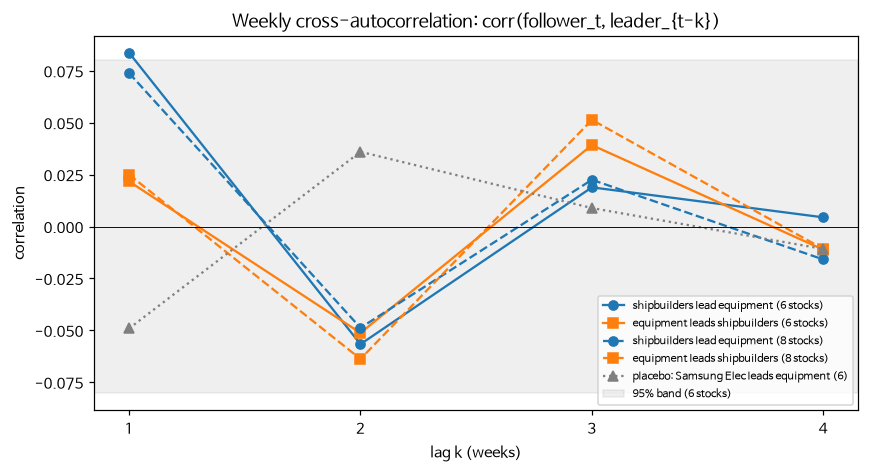

In [9]:
# ---- I-1. 교차상관 비대칭성 (k=1..4) + 이동블록 부트스트랩 ----
K = 4
def lagcorr(a, b, k):                                  # corr(a_t, b_{t-k})
    x, y = a.values[k:], b.values[:-k]
    ok = ~np.isnan(x) & ~np.isnan(y)
    return np.corrcoef(x[ok], y[ok])[0, 1]
def asym_stat(F, L, K=K):
    return sum(lagcorr(F, L, k) for k in range(1, K + 1)) - sum(lagcorr(L, F, k) for k in range(1, K + 1))
def mbb_se(F, L, block, B=2000, seed=42):
    rng = np.random.default_rng(seed); n = len(F); nb = int(np.ceil(n / block))
    Fv, Lv, out = F.values, L.values, []
    for _ in range(B):
        st = rng.integers(0, n - block + 1, nb)
        ix = np.concatenate([np.arange(s, s + block) for s in st])[:n]
        out.append(asym_stat(pd.Series(Fv[ix]), pd.Series(Lv[ix])))
    return np.nanstd(out)

rows = []
for (fq, u), s in SER.items():
    F, L = s["F"], s["L"]
    blk = 8 if fq == "W" else 20
    A = asym_stat(F, L); se = mbb_se(F, L, blk); z = A / se
    n = int(pd.concat([F, L], axis=1).dropna().shape[0])
    r = {"freq": "주간" if fq == "W" else "일간", "universe": u, "N": n, "band(±1.96/√N)": 1.96 / np.sqrt(n)}
    for k in range(1, K + 1):
        r[f"L→F k={k}"] = lagcorr(F, L, k); r[f"F→L k={k}"] = lagcorr(L, F, k)
    r.update({"Σ(L→F) − Σ(F→L)": A, "boot SE": se, "z": z, "p": 2 * (1 - stats.norm.cdf(abs(z)))})
    rows.append(r)
tblI1 = pd.DataFrame(rows).set_index(["freq", "universe"])
display(tblI1.T); tblI1.to_csv(f"{RES_DIR}/I1_ccf_asymmetry.csv", encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(8, 4.4)); ks_ = np.arange(1, K + 1)
for u, ls in [("6종목(본 분석)", "-"), ("8종목(강건성)", "--")]:
    F, L = SER[("W", u)]["F"], SER[("W", u)]["L"]
    lab = "6 stocks" if u.startswith("6") else "8 stocks"
    ax.plot(ks_, [lagcorr(F, L, k) for k in ks_], ls, marker="o", color="tab:blue", label=f"shipbuilders lead equipment ({lab})")
    ax.plot(ks_, [lagcorr(L, F, k) for k in ks_], ls, marker="s", color="tab:orange", label=f"equipment leads shipbuilders ({lab})")
S6 = SER[("W", "6종목(본 분석)")]
ax.plot(ks_, [lagcorr(S6["F"], S6["S"], k) for k in ks_], ":", marker="^", color="grey", label="placebo: Samsung Elec leads equipment (6)")
b = tblI1.loc[("주간", "6종목(본 분석)"), "band(±1.96/√N)"]
ax.axhspan(-b, b, color="grey", alpha=0.12, label="95% band (6 stocks)"); ax.axhline(0, color="k", lw=0.6)
ax.set_xticks(ks_); ax.set_xlabel("lag k (weeks)"); ax.set_ylabel("correlation")
ax.set_title("Weekly cross-autocorrelation: corr(follower_t, leader_{t-k})"); ax.legend(fontsize=7)
plt.tight_layout(); plt.savefig(f"{RES_DIR}/fig_I1_ccf.png", bbox_inches="tight"); plt.show()

In [10]:
# ---- I-2·I-3·I-4. 예측 회귀 (HAC): y_t = a + Σb·x_{t-k} + Σc·y_{t-k} + Σd·시장_{t-k}, k=1..4 ----
def lags(s, name, K=K): return pd.concat({f"{name}{k}": s.shift(k) for k in range(1, K + 1)}, axis=1)
def lead_reg(y, x, mkt, hac):
    X = pd.concat([lags(x, "x"), lags(y, "own"), lags(mkt, "mkt")], axis=1)
    d = pd.concat([y.rename("y"), X], axis=1).dropna()
    res = sm.OLS(d["y"], sm.add_constant(d.drop(columns="y"))).fit(cov_type="HAC", cov_kwds={"maxlags": hac})
    xs = [f"x{k}" for k in range(1, K + 1)]
    tt = res.t_test(" + ".join(xs) + " = 0")
    ft = res.f_test(", ".join(f"{v} = 0" for v in xs))
    out = {"N": int(res.nobs), "Σb": float(np.squeeze(tt.effect)), "Σb t": float(np.squeeze(tt.tvalue)),
           "Σb p": float(np.squeeze(tt.pvalue)), "joint F p (b=0)": float(np.squeeze(ft.pvalue)), "R2": res.rsquared}
    out.update({f"b{k}": res.params[f"x{k}"] for k in range(1, K + 1)})
    return out

TESTS = {"I-2 조선→기자재": ("F", "L", "MF"), "I-3 플라시보 삼성전자→기자재": ("F", "S", "MF"),
         "I-4 역방향 기자재→조선": ("L", "F", "MK")}
rows = []
for (fq, u), s in SER.items():
    for t, (yk, xk, mk) in TESTS.items():
        r = lead_reg(s[yk], s[xk], s[mk], hac=4 if fq == "W" else 5)
        rows.append({"test": t, "freq": "주간" if fq == "W" else "일간", "universe": u, **r})
tblI2 = pd.DataFrame(rows).set_index(["test", "freq", "universe"])
display(tblI2); tblI2.to_csv(f"{RES_DIR}/I2_predictive_regressions.csv", encoding="utf-8-sig")

,,,N,Σb,Σb t,Σb p,joint F p (b=0),R2,b1,b2,b3,b4
test,freq,universe,,,,,,,,,,
I-2 조선→기자재,주간,6종목(본 분석),537,0.15,1.30,0.19,0.20,0.03,0.13,0.02,0.01,-0.01
I-3 플라시보 삼성전자→기자재,주간,6종목(본 분석),533,-0.08,-0.43,0.67,0.95,0.02,-0.05,0.00,0.00,-0.03
I-4 역방향 기자재→조선,주간,6종목(본 분석),537,0.07,0.55,0.58,0.64,0.03,0.06,-0.05,0.02,0.05
I-2 조선→기자재,일간,6종목(본 분석),2870,0.04,0.92,0.36,0.46,0.01,0.01,-0.01,0.04,-0.00
I-3 플라시보 삼성전자→기자재,일간,6종목(본 분석),2863,0.02,0.26,0.80,0.91,0.01,0.03,0.00,-0.02,0.01
I-4 역방향 기자재→조선,일간,6종목(본 분석),2870,0.19,2.94,0.00,0.05,0.01,0.06,0.04,0.04,0.06
I-2 조선→기자재,주간,8종목(강건성),537,0.08,0.74,0.46,0.73,0.02,0.06,-0.00,0.03,-0.01
I-3 플라시보 삼성전자→기자재,주간,8종목(강건성),533,-0.01,-0.04,0.97,0.97,0.02,0.01,-0.00,-0.05,0.04
I-4 역방향 기자재→조선,주간,8종목(강건성),537,0.05,0.52,0.61,0.29,0.04,0.06,-0.09,0.04,0.04


CAGR(%)  Sharpe  MDD(%)  승률(%)  보유 주  진입 횟수
universe  period      strategy                                                          
6종목(본 분석) 전체          전략: 조선 상위30% → 기자재 1주     6.10    0.29  -37.83  53.80   158 109.00
                      기자재 단순보유                 23.37    0.62  -50.45  52.67   505    NaN
                      조선 단순보유                  14.79    0.37  -56.41  51.88   505    NaN
          ~2020 (IS)  전략: 조선 상위30% → 기자재 1주    -3.52   -0.21  -26.13  49.06    53    NaN
                      기자재 단순보유                 21.69    0.60  -50.36  52.17   207    NaN
                      조선 단순보유                  -0.25   -0.01  -56.41  48.31   207    NaN
          2021~ (OOS) 전략: 조선 상위30% → 기자재 1주    13.34    0.56  -34.46  56.19   105    NaN
                      기자재 단순보유                 24.55    0.63  -50.45  53.02   298    NaN
                      조선 단순보유                  26.55    0.67  -43.65  54.36   298    NaN
8종목(강건성)  전체          전략: 조선 상위30% → 기자재 1주     7.05    0.33  -41.04  51.27   158 109.00
                      기자재 단순보유                 20.98    0.53  -61.35  52.67   505    NaN
                      조선 단순보유                  14.79    0.37  -56.41  51.88   505    NaN
          ~2020 (IS)  전략: 조선 상위30% → 기자재 1주    -5.27   -0.32  -29.61  43.40    53    NaN
                      기자재 단순보유                  7.51    0.20  -61.35  51.21   207    NaN
                      조선 단순보유                  -0.25   -0.01  -56.41  48.31   207    NaN
          2021~ (OOS) 전략: 조선 상위30% → 기자재 1주    16.53    0.68  -21.33  55.24   105    NaN
                      기자재 단순보유                 31.32    0.76  -52.26  53.69   298    NaN
                      조선 단순보유                  26.55    0.67  -43.65  54.36   298    NaN

평가 구간: 2017-01-20 ~ 2026-09-18 (조선 신호 백분위가 104주 쌓인 뒤부터)


CAGR(%)  Sharpe  MDD(%)  승률(%)  보유 주  진입 횟수  기자재 보유 CAGR(%)  전략 − 보유 CAGR(%p)
universe  threshold hold(weeks)                                                                               
6종목(본 분석) 상위 20%    1               5.29    0.29  -35.07  55.56   108     84           23.37            -18.08
                    2               7.38    0.32  -44.80  56.25   192     60           23.37            -15.99
                    4              16.58    0.59  -38.56  55.96   302     41           23.37             -6.79
          상위 30%    1               6.10    0.29  -37.83  53.80   158    109           23.37            -17.27
                    2              11.47    0.44  -30.10  54.31   267     73           23.37            -11.90
                    4              19.94    0.62  -33.95  53.37   386     36           23.37             -3.43
          상위 40%    1               7.16    0.31  -43.61  51.24   201    123           23.37            -16.21
                    2               7.28    0.26  -45.25  50.93   324     78           23.37            -16.09
                    4              23.12    0.68  -43.20  52.50   440     25           23.37             -0.25
8종목(강건성)  상위 20%    1               5.27    0.29  -40.31  52.78   108     84           20.98            -15.71
                    2               7.59    0.33  -49.21  55.21   192     60           20.98            -13.39
                    4              15.92    0.54  -43.34  54.64   302     41           20.98             -5.06
          상위 30%    1               7.05    0.33  -41.04  51.27   158    109           20.98            -13.94
                    2              12.18    0.46  -37.36  54.68   267     73           20.98             -8.80
                    4              19.19    0.57  -37.01  53.37   386     36           20.98             -1.79
          상위 40%    1               8.84    0.36  -32.95  49.75   201    123           20.98            -12.14
                    2               8.21    0.28  -47.07  50.93   324     78           20.98            -12.77
                    4              22.15    0.62  -43.59  52.05   440     25           20.98              1.17

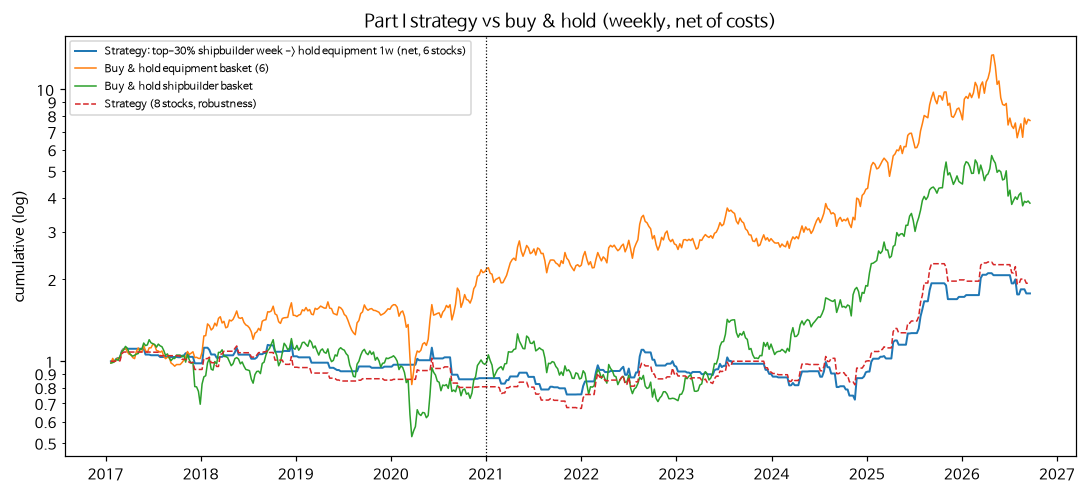

In [11]:
# ---- I-5. 전략: 조선 주간 초과수익 상위 30%(expanding, 최소 104주) → 다음 거래일 시가 매수, 그 주 금요일 종가 매도 ----
first_day = WEEK.groupby(WEEK).apply(lambda s: s.index[0]).reindex(WIDX)
last_day = WEEK.groupby(WEEK).apply(lambda s: s.index[-1]).reindex(WIDX)
Cf = C.ffill()                                                   # 정지 중 보유분은 마지막 가격으로 평가
def week_legs(cols):
    ent, cont = {}, {}
    for c in cols:
        o = pd.Series([O[c].get(d, np.nan) if pd.notna(d) and V[c].get(d, 0) > 0 else np.nan for d in first_day], index=WIDX)
        cl = pd.Series([Cf[c].get(d, np.nan) if pd.notna(d) else np.nan for d in last_day], index=WIDX)
        cl = cl.where(C[c].notna().cumsum().reindex(last_day.values).values > 0)   # 상장 전 제외
        ent[c], cont[c] = cl / o - 1, cl / cl.shift(1) - 1
    return pd.DataFrame(ent).mean(axis=1), pd.DataFrame(cont).mean(axis=1)

def run_strategy(sig_src, cols, thr, hold):
    rank = sig_src.expanding(min_periods=104).rank(pct=True)
    sig = (rank >= thr).astype(float).where(rank.notna(), 0.0)
    pos = sum(sig.shift(k) for k in range(1, hold + 1)).fillna(0).clip(0, 1)       # 최근 hold주 안에 신호 → 보유
    entry = (pos > 0) & (pos.shift(1, fill_value=0) == 0)
    exit_ = (pos > 0) & (pos.shift(-1, fill_value=0) == 0)
    E, Kc = week_legs(cols)
    gross = np.where(entry, E, Kc) * pos
    net = pd.Series(gross, index=WIDX).fillna(0) - entry * COST_BUY - exit_ * COST_SELL
    start = rank.first_valid_index()
    return net.loc[start:], pos.loc[start:], int(entry.loc[start:].sum())

def wmet(r, pos=None):
    r = r.dropna()
    if len(r) < 20: return {}
    cagr = (1 + r).prod() ** (52 / len(r)) - 1; vol = r.std() * np.sqrt(52)
    eq = (1 + r).cumprod(); mdd = (eq / eq.cummax() - 1).min()
    held = r[pos.reindex(r.index) > 0] if pos is not None else r
    return {"CAGR(%)": cagr * 100, "Sharpe": cagr / vol if vol > 0 else np.nan, "MDD(%)": mdd * 100,
            "승률(%)": (held > 0).mean() * 100, "보유 주": len(held)}

LS = SER[("W", "6종목(본 분석)")]["L"]
rows, curves = [], {}
for u, cols in UNIS.items():
    net, pos, n_ent = run_strategy(LS, cols, 0.7, 1)
    _, Kf = week_legs(cols); _, Kl = week_legs(LEAD)
    bhF, bhL = Kf.loc[net.index].fillna(0), Kl.loc[net.index].fillna(0)
    curves[u] = (net, bhF, bhL)
    for per, sl in [("전체", slice(None, None)), ("~2020 (IS)", slice(None, pd.Period(IS_END, "W-FRI"))),
                    ("2021~ (OOS)", slice(pd.Period("2021-01-08", "W-FRI"), None))]:
        for lab, r, p in [("전략: 조선 상위30% → 기자재 1주", net, pos), ("기자재 단순보유", bhF, None), ("조선 단순보유", bhL, None)]:
            m = wmet(r.loc[sl], p.loc[sl] if p is not None else None)
            rows.append({"universe": u, "period": per, "strategy": lab, **m,
                         "진입 횟수": n_ent if (lab.startswith("전략") and per == "전체") else np.nan})
tblI3 = pd.DataFrame(rows).set_index(["universe", "period", "strategy"])
display(tblI3); tblI3.to_csv(f"{RES_DIR}/I3_strategy.csv", encoding="utf-8-sig")
print(f"평가 구간: {net.index[0].end_time.date()} ~ {net.index[-1].end_time.date()} (조선 신호 백분위가 104주 쌓인 뒤부터)")

grid = []
for u, cols in UNIS.items():
    _, Kf = week_legs(cols)
    for thr, lab in [(0.8, "상위 20%"), (0.7, "상위 30%"), (0.6, "상위 40%")]:
        for hold in [1, 2, 4]:
            net, pos, n_ent = run_strategy(LS, cols, thr, hold)
            m, mb = wmet(net, pos), wmet(Kf.loc[net.index].fillna(0))
            grid.append({"universe": u, "threshold": lab, "hold(weeks)": hold, **m, "진입 횟수": n_ent,
                         "기자재 보유 CAGR(%)": mb["CAGR(%)"], "전략 − 보유 CAGR(%p)": m["CAGR(%)"] - mb["CAGR(%)"]})
tblI4 = pd.DataFrame(grid).set_index(["universe", "threshold", "hold(weeks)"])
display(tblI4); tblI4.to_csv(f"{RES_DIR}/I4_strategy_sensitivity.csv", encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(10, 4.6))
net, bhF, bhL = curves["6종목(본 분석)"]
x = [p.end_time for p in net.index]
ax.plot(x, (1 + net).cumprod(), lw=1.3, label="Strategy: top-30% shipbuilder week -> hold equipment 1w (net, 6 stocks)")
ax.plot(x, (1 + bhF).cumprod(), lw=1.0, label="Buy & hold equipment basket (6)")
ax.plot(x, (1 + bhL).cumprod(), lw=1.0, label="Buy & hold shipbuilder basket")
net8 = curves["8종목(강건성)"][0]
ax.plot(x, (1 + net8.reindex(net.index).fillna(0)).cumprod(), "--", lw=1.0, label="Strategy (8 stocks, robustness)")
ax.axvline(pd.Timestamp(IS_END), color="k", ls=":", lw=0.8); ax.set_yscale("log")
from matplotlib.ticker import FuncFormatter
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}")); ax.yaxis.set_minor_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
ax.set_ylabel("cumulative (log)"); ax.legend(fontsize=7); ax.set_title("Part I strategy vs buy & hold (weekly, net of costs)")
plt.tight_layout(); plt.savefig(f"{RES_DIR}/fig_I2_strategy.png", bbox_inches="tight"); plt.show()

In [12]:
# ---- I-6. 6종목 vs 8종목 나란히 + 다중검정 기준 ----
cmp = []
for fq in ["주간", "일간"]:
    r = {"항목": f"I-1 비대칭 Σ(L→F)−Σ(F→L) [{fq}]"}
    for u in UNIS:
        a = tblI1.loc[(fq, u)]; r[u] = f"{a['Σ(L→F) − Σ(F→L)']:+.3f} (p={a['p']:.3f})"
    cmp.append(r)
    for t in TESTS:
        r = {"항목": f"{t} Σb [{fq}]"}
        for u in UNIS:
            a = tblI2.loc[(t, fq, u)]; r[u] = f"{a['Σb']:+.3f} (t={a['Σb t']:.2f}, p={a['Σb p']:.3f}; 결합 p={a['joint F p (b=0)']:.3f})"
        cmp.append(r)
for per in ["전체", "~2020 (IS)", "2021~ (OOS)"]:
    r = {"항목": f"전략 CAGR / Sharpe [{per}]"}
    for u in UNIS:
        a = tblI3.loc[(u, per, "전략: 조선 상위30% → 기자재 1주")]; b = tblI3.loc[(u, per, "기자재 단순보유")]
        r[u] = f"{a['CAGR(%)']:.1f}% / {a['Sharpe']:.2f} (보유 {b['CAGR(%)']:.1f}% / {b['Sharpe']:.2f})"
    cmp.append(r)
tblI5 = pd.DataFrame(cmp).set_index("항목"); display(tblI5)
tblI5.to_csv(f"{RES_DIR}/I5_compare_6_vs_8.csv", encoding="utf-8-sig")

n_primary = 4          # 주간·6종목: I-1 비대칭, I-2 Σb, I-3 Σb, I-4 Σb
n_all = len(tblI1) + 2 * len(tblI2)   # 비대칭 4 + (Σb, 결합) × 12
print(f"Part I 검정 수 — 1차(주간·본 분석) {n_primary}개 → 보정 기준 p < {0.05/n_primary:.4f}")
print(f"                전체(주간·일간 × 6·8종목, 결합검정 포함) {n_all}개 → 보정 기준 p < {0.05/n_all:.5f}")

,6종목(본 분석),8종목(강건성)
항목,,
I-1 비대칭 Σ(L→F)−Σ(F→L) [주간],+0.052 (p=0.555),+0.030 (p=0.735)
I-2 조선→기자재 Σb [주간],"+0.149 (t=1.30, p=0.193; 결합 p=0.202)","+0.077 (t=0.74, p=0.460; 결합 p=0.730)"
I-3 플라시보 삼성전자→기자재 Σb [주간],"-0.075 (t=-0.43, p=0.669; 결합 p=0.949)","-0.008 (t=-0.04, p=0.968; 결합 p=0.967)"
I-4 역방향 기자재→조선 Σb [주간],"+0.074 (t=0.55, p=0.579; 결합 p=0.635)","+0.053 (t=0.52, p=0.606; 결합 p=0.295)"
I-1 비대칭 Σ(L→F)−Σ(F→L) [일간],-0.042 (p=0.306),-0.008 (p=0.859)
I-2 조선→기자재 Σb [일간],"+0.041 (t=0.92, p=0.359; 결합 p=0.462)","+0.033 (t=0.70, p=0.483; 결합 p=0.858)"
I-3 플라시보 삼성전자→기자재 Σb [일간],"+0.017 (t=0.26, p=0.795; 결합 p=0.908)","+0.044 (t=0.67, p=0.501; 결합 p=0.965)"
I-4 역방향 기자재→조선 Σb [일간],"+0.194 (t=2.94, p=0.003; 결합 p=0.046)","+0.160 (t=2.80, p=0.005; 결합 p=0.062)"
전략 CAGR / Sharpe [전체],6.1% / 0.29 (보유 23.4% / 0.62),7.0% / 0.33 (보유 21.0% / 0.53)


Part I 검정 수 — 1차(주간·본 분석) 4개 → 보정 기준 p < 0.0125
                전체(주간·일간 × 6·8종목, 결합검정 포함) 28개 → 보정 기준 p < 0.00179


---
# Part J. 거리 기반 페어트레이딩 (Gatev, Goetzmann & Rouwenhorst 2006 방식)
Part D(공적분)는 2015~2026 전체 표본으로 페어를 골라 선택 편향이 있었음. 여기서는 **항상 과거(형성 기간)로만 고르고 그다음 기간에 거래**함.

| 항목 | 설정 (미리 정한 값, 바꾸지 않음) |
|---|---|
| 유니버스 | Part D와 같은 조선 6종목: HD한국조선해양, 삼성중공업, 한화오션, HD현대중공업, HD현대미포, HJ중공업 |
| 형성 기간 | 252거래일. 형성 시작일 = 1로 정규화한 가격끼리 차이 제곱합(SSD) → 가장 작은 3쌍 |
| 거래 기간 | 126거래일. \|정규화 가격 차이\| ≥ 2 × 형성 기간 표준편차면 진입(싼 쪽 롱, 비싼 쪽 숏), 두 가격이 교차하면 청산, 기간 끝에 강제 청산 |
| 체결 | 신호 다음 거래일 종가 (GGR 하루 대기) |
| 재형성 | 126거래일마다, 거래 기간이 겹치지 않게. 보조: 매월 첫 거래일 시작하는 중첩 6개 포트폴리오 평균 |
| 수익률 | 선택된 3쌍 전체 자본 기준(committed capital). 쌍마다 자본 1/3, 진입 시 롱·숏 각각 그 쌍 자본만큼 |
| 비용 | 수수료 0.015%(양쪽 다리 매수·매도), 거래세 0.20%(롱 매도와 공매도 매도에 부과, Part I와 같은 2026년 세율), 숏 다리 대차수수료 연 3% (252일로 일할) |
| 기간 | 2015-01-02 ~ 2026-09-17 (Part D·I와 같은 끝 날짜). 첫 거래 기간은 2016년 1월 시작 |

**구현상 결정 (결과를 보기 전에 정함)**
- 형성 기간 "데이터 온전": 형성 252일 **매일 거래가 있었던(거래량 > 0) 종목만** 사용. GGR 원문의 "거래 없는 날이 하루라도 있으면 제외" 규칙과 같음. 정지일이 있던 한화오션(2016~2017)·HD한국조선해양(2017)·삼성중공업(2021)·HJ중공업(2019)은 해당 형성 기간에서 빠지고, HD현대중공업은 상장(2021-09-17) 후 252일이 지나야 들어옴.
- 거래 기간 정규화 가격: 형성 마지막 날 종가 = 1로 다시 정규화 (Do & Faff 2010 등 GGR 재현 연구의 관행). 진입 기준 σ는 형성 기간의 정규화 가격 차이 표준편차.
- 교차 판정: 진입 방향 기준으로 가격 차이의 부호가 바뀌거나 0이 되면 청산 신호. 청산 뒤 같은 쌍의 재진입 허용 (GGR과 같음).
- 체결일에 해당 종목이 거래정지면: 진입은 취소(다음 날 종가에 신호를 다시 판단), 청산은 거래 가능한 첫날로 미룸. 기간 끝까지 거래가 안 되면 마지막 가격으로 청산하고 "stale"로 표시함. HD현대미포(2025-12 합병 상장폐지)도 같은 방식임.
- 수익률: 매일 종가로 평가한 committed capital 가치의 변화. 쌍이 3개가 안 되면 남는 자본은 현금(이자 0).

**공매도 제약 (정확한 날짜, 출처는 요약 파일)**

| 기간 | 제도 | (b)에서의 처리 |
|---|---|---|
| ~2020-03-13 | 허용 | 진입 가능 |
| 2020-03-16 ~ 2021-05-02 | 전 종목 금지 | 신규 진입 금지 |
| 2021-05-03 ~ 2023-11-05 | KOSPI200·KOSDAQ150 구성 종목만 허용 | 구성 종목이 숏 다리일 때만 진입 |
| 2023-11-06 ~ 2025-03-30 | 전 종목 금지 | 신규 진입 금지 |
| 2025-03-31 ~ | 전면 재개 | 진입 가능 |

- 부분 재개 기간의 KOSPI200 구성: HD한국조선해양·삼성중공업·한화오션·HD현대미포는 구성 종목으로 처리함(대형주, 편출 기록 확인 못함 — **추정**). HD현대중공업은 2021-12-10 정기변경 편입부터 허용함. HJ중공업은 2019년 관리종목 지정 뒤 편출 예고 보도가 있고 재편입 기록을 찾지 못해 **불가로 처리함(보수적)**. KRX 구성종목 조회는 로그인이 필요해 직접 확인하지 못함.
- 금지 기간에도 이미 들고 있던 숏 포지션은 유지함(당시 규정상 신규 공매도만 금지).
- 세 버전 (a) 이론: 제약 무시, (b) 실행 가능: 숏 다리 종목의 공매도가 막힌 날에는 신규 진입 금지, (c) 롱온리: 같은 신호에서 싼 쪽만 매수.

In [2]:
# ---- J-0. 데이터: Part D와 같은 조선 6종목 (+ 탐색용 기자재 본 분석 6종목), 네이버 수정주가 ----
import time
from itertools import combinations
import statsmodels.api as sm
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pykrx import stock

SHIP6 = {"009540": "HD한국조선해양", "010140": "삼성중공업", "042660": "한화오션",
         "329180": "HD현대중공업", "010620": "HD현대미포", "097230": "HJ중공업"}
_u = pd.read_csv(f"{RES_DIR}/universe.csv", dtype={"code": str}).set_index("code")
EQ6 = {c: _u.loc[c, "name"] for c in _u.index if str(_u.loc[c, "분석 구분"]).startswith("본 분석")}
NMJ = {**SHIP6, **EQ6}
ENJ = {"009540": "HD KSOE", "010140": "Samsung HI", "042660": "Hanwha Ocean", "329180": "HD HHI",
       "010620": "HD Mipo", "097230": "HJ S&C", "017960": "Korea Carbon", "033500": "Dongsung Finetec",
       "075580": "Sejin HI", "014620": "Sungkwang Bend", "023160": "Taekwang", "082740": "Hanwha Engine"}
J_END = "2026-09-17"                                   # Part D·Part I와 같은 마지막 날 (비교 가능성)
FORM, TRADE, K_SIG, N_PAIRS = 252, 126, 2.0, 3         # 미리 정한 값 — 바꾸지 않음
BORROW = 0.03
COST_BUY_J, COST_SELL_J = 0.00015, 0.00015 + 0.0020   # 매도(롱 청산·공매도 진입)에 거래세 0.20%

PJ, VJ = {}, {}
for c in NMJ:
    df = stock.get_market_ohlcv(START.replace("-", ""), J_END.replace("-", ""), c)
    df.index = pd.to_datetime(df.index)
    PJ[c], VJ[c] = df["종가"], df["거래량"]
    time.sleep(0.3)
PJ, VJ = pd.DataFrame(PJ).sort_index(), pd.DataFrame(VJ).sort_index()
DJ = PJ.index
TRJ = (VJ > 0) & PJ.notna()                            # 실제로 거래가 된 날
PXJ = PJ.ffill()                                       # 정지·상장폐지 뒤 평가는 마지막 가격
chkJ = pd.DataFrame({"name": pd.Series(NMJ), "구분": pd.Series({c: ("조선" if c in SHIP6 else "기자재(탐색용)") for c in NMJ}),
                     "시작": PJ.apply(lambda s: s.first_valid_index().date()),
                     "마지막 거래일": TRJ.apply(lambda s: s[s].index.max().date()),
                     "거래일": TRJ.sum(), "거래량 0인 날": ((VJ == 0) & PJ.notna()).sum()}).loc[list(NMJ)]
display(chkJ)
print(f"달력: {DJ[0].date()} ~ {DJ[-1].date()} ({len(DJ)}거래일)")

KRX 로그인 실패: KRX_ID 또는 KRX_PW 환경 변수가 설정되지 않았습니다.


,name,구분,시작,마지막 거래일,거래일,거래량 0인 날
009540,HD한국조선해양,조선,2015-01-02,2026-09-17,2850,25
010140,삼성중공업,조선,2015-01-02,2026-09-17,2863,12
042660,한화오션,조선,2015-01-02,2026-09-17,2560,315
329180,HD현대중공업,조선,2021-09-17,2026-09-17,1222,0
010620,HD현대미포,조선,2015-01-02,2025-11-26,2677,12
097230,HJ중공업,조선,2015-01-02,2026-09-17,2815,60
017960,한국카본,기자재(탐색용),2015-01-02,2026-09-17,2875,0
033500,동성화인텍,기자재(탐색용),2015-01-02,2026-09-17,2862,13
075580,세진중공업,기자재(탐색용),2015-11-30,2026-09-17,2649,0
014620,성광벤드,기자재(탐색용),2015-01-02,2026-09-17,2875,0


달력: 2015-01-02 ~ 2026-09-17 (2875거래일)


In [3]:
# ---- J-0b. 종목·날짜별 공매도 가능 여부 ----
BAN_FULL = [("2020-03-16", "2021-05-02"), ("2023-11-06", "2025-03-30")]
PARTIAL = ("2021-05-03", "2023-11-05")                 # KOSPI200·KOSDAQ150 구성 종목만 허용
K200_FROM = {"009540": "2021-05-03", "010140": "2021-05-03", "042660": "2021-05-03", "010620": "2021-05-03",
             "329180": "2021-12-10"}                   # 부분 재개 기간 중 구성 종목으로 보는 시작일. 없는 종목은 불가(보수적)
SOKJ = pd.DataFrame(True, index=DJ, columns=list(NMJ))
for a_, b_ in BAN_FULL:
    SOKJ.loc[a_:b_] = False
mp = (DJ >= PARTIAL[0]) & (DJ <= PARTIAL[1])
for c in SOKJ.columns:
    SOKJ.loc[mp, c] = (DJ[mp] >= pd.Timestamp(K200_FROM[c])) if c in K200_FROM else False
K200_NOTE = {"009540": "구성 종목으로 처리(대형주, 편출 기록 확인 못함 — 추정)", "010140": "구성 종목으로 처리(추정)",
             "042660": "구성 종목으로 처리(추정)", "010620": "구성 종목으로 처리(추정)",
             "329180": "2021-12-10 정기변경 편입(보도 확인) → 그 전은 불가",
             "097230": "2019년 관리종목 지정 뒤 편출 예고 보도, 재편입 기록 못 찾음 → 불가(보수적)"}
rulesJ = pd.DataFrame({"name": pd.Series(NMJ),
                       "부분 재개기간(2021-05-03~2023-11-05) 처리": pd.Series({c: K200_NOTE.get(c, "KOSDAQ150/KOSPI200 구성 확인 못함 → 불가(보수적, 탐색용)") for c in NMJ}),
                       "공매도 가능 거래일 비율(%)": SOKJ.loc[DJ[FORM]:].mean() * 100}).loc[list(NMJ)]
rulesJ.to_csv(f"{RES_DIR}/J0_short_sale_rules.csv", encoding="utf-8-sig")
display(rulesJ)

,name,부분 재개기간(2021-05-03~2023-11-05) 처리,공매도 가능 거래일 비율(%)
009540,HD한국조선해양,"구성 종목으로 처리(대형주, 편출 기록 확인 못함 — 추정)",76.40
010140,삼성중공업,구성 종목으로 처리(추정),76.40
042660,한화오션,구성 종목으로 처리(추정),76.40
329180,HD현대중공업,2021-12-10 정기변경 편입(보도 확인) → 그 전은 불가,70.64
010620,HD현대미포,구성 종목으로 처리(추정),76.40
097230,HJ중공업,"2019년 관리종목 지정 뒤 편출 예고 보도, 재편입 기록 못 찾음 → 불가(보수적)",52.80
017960,한국카본,"KOSDAQ150/KOSPI200 구성 확인 못함 → 불가(보수적, 탐색용)",52.80
033500,동성화인텍,"KOSDAQ150/KOSPI200 구성 확인 못함 → 불가(보수적, 탐색용)",52.80
075580,세진중공업,"KOSDAQ150/KOSPI200 구성 확인 못함 → 불가(보수적, 탐색용)",52.80
014620,성광벤드,"KOSDAQ150/KOSPI200 구성 확인 못함 → 불가(보수적, 탐색용)",52.80


In [4]:
# ---- J-1. GGR 엔진 ----
P_, TR_, SOK_ = PXJ.values, TRJ.values, SOKJ.values
COLJ = list(PXJ.columns)

def form_pairs(cols, f0, s0):
    """형성 기간 f0..s0 (252일). 매일 거래가 있던 종목만. SSD 오름차순 상위 N_PAIRS."""
    elig = [j for j in cols if TR_[f0:s0 + 1, j].all()]
    cand = []
    for a, b in combinations(elig, 2):
        sp = P_[f0:s0 + 1, a] / P_[f0, a] - P_[f0:s0 + 1, b] / P_[f0, b]
        cand.append((float((sp ** 2).sum()), a, b, float(sp.std(ddof=1))))
    cand.sort()
    return elig, cand[:N_PAIRS], len(cand)

def run_pair(a, b, s0, t0, t1, sig, ver, K0):
    """거래 기간 t0..t1-1. 정규화 기준 = s0 종가. 신호는 당일 종가, 체결은 다음 거래일 종가."""
    K, d, L, S, vL, vS, pend, tr = K0, 0, None, None, 0.0, 0.0, None, None
    val, trades, blocked = np.empty(t1 - t0), [], 0
    for i in range(t0, t1):
        last = i == t1 - 1
        if d != 0:                                             # 전일 종가 → 당일 종가 평가
            rl = P_[i, L] / P_[i - 1, L] - 1; K += vL * rl; vL *= 1 + rl
            if ver != "c":
                rs = P_[i, S] / P_[i - 1, S] - 1; K -= vS * rs + vS * BORROW / 252; vS *= 1 + rs
            tr["days"] += 1
        if d != 0 and (pend == "exit" or last):                # 청산 체결 (기간 마지막 날은 강제)
            ok = TR_[i, L] and (ver == "c" or TR_[i, S])
            if ok or last:
                K -= vL * COST_SELL_J + vS * COST_BUY_J
                tr.update(exit=DJ[i], ret=K / tr["N"] - 1, forced=(pend != "exit"), stale=not ok)
                trades.append(tr); d, vL, vS, pend, tr = 0, 0.0, 0.0, None, None
        elif d == 0 and pend is not None:                      # 진입 체결
            dd, pend = pend, None
            Lc, Sc = (a, b) if dd > 0 else (b, a)
            ok = TR_[i, Lc] and (ver == "c" or TR_[i, Sc])
            if ok and ver == "b" and not SOK_[i, Sc]:
                ok, blocked = False, blocked + 1
            if ok and not last:
                d, L, S, N = dd, Lc, Sc, K
                vL, vS = N, (N if ver != "c" else 0.0)
                K -= vL * COST_BUY_J + vS * COST_SELL_J
                tr = {"ver": ver, "long": COLJ[L], "short": COLJ[S], "entry": DJ[i], "N": N, "days": 0,
                      "short 가능(체결일)": bool(SOK_[i, S])}
        if not last and pend is None:                          # 당일 종가 신호 → 다음 날 체결
            spr = P_[i, a] / P_[s0, a] - P_[i, b] / P_[s0, b]
            if d == 0 and abs(spr) >= K_SIG * sig:
                pend = 1 if spr < 0 else -1                    # +1: a 롱·b 숏 (a가 싼 쪽)
            elif d != 0 and spr * d >= 0:
                pend = "exit"
        val[i - t0] = K
    return val, trades, blocked

def run_cohort(cols, t0, t1):
    f0, s0 = t0 - FORM, t0 - 1
    elig, top, ncand = form_pairs(cols, f0, s0)
    out = {"trades": []}
    cash = (N_PAIRS - len(top)) / N_PAIRS
    for ver in "abc":
        tot, blk = np.full(t1 - t0, cash), 0
        for k, (ssd, a, b, sig) in enumerate(top):
            v, trs, bl = run_pair(a, b, s0, t0, t1, sig, ver, 1 / N_PAIRS)
            tot += v; blk += bl
            for t in trs:
                t.update(pair=f"{NMJ[COLJ[a]]} / {NMJ[COLJ[b]]}", rank=k + 1, period_start=DJ[t0])
                out["trades"].append(t)
        out[ver], out[f"blocked_{ver}"] = pd.Series(tot, index=DJ[t0:t1]), blk
    bh = np.full(t1 - t0, cash)                               # 비교: 선택된 쌍의 두 종목 50:50 상시 보유 (비용 없음)
    for ssd, a, b, sig in top:
        bh += 0.5 / N_PAIRS * (P_[t0:t1, a] / P_[s0, a] + P_[t0:t1, b] / P_[s0, b])
    out["bench"] = pd.Series(bh, index=DJ[t0:t1])
    info = {"형성 시작": DJ[f0].date(), "형성 끝": DJ[s0].date(), "거래 시작": DJ[t0].date(), "거래 끝": DJ[t1 - 1].date(),
            "거래일": t1 - t0, "적격 종목 수": len(elig), "적격 종목": ", ".join(NMJ[COLJ[j]] for j in elig), "후보 쌍 수": ncand}
    for k in range(N_PAIRS):
        if k < len(top):
            ssd, a, b, sig = top[k]
            info.update({f"{k + 1}위 쌍": f"{NMJ[COLJ[a]]} / {NMJ[COLJ[b]]}", f"{k + 1}위 SSD": ssd, f"{k + 1}위 σ": sig})
        else:
            info.update({f"{k + 1}위 쌍": "", f"{k + 1}위 SSD": np.nan, f"{k + 1}위 σ": np.nan})
    out["info"], out["pairs"] = info, [(COLJ[a], COLJ[b]) for _, a, b, _ in top]
    return out

def to_ret(v):
    r = v / v.shift(1) - 1; r.iloc[0] = v.iloc[0] - 1                 # 기간 시작 가치 = 1
    return r

def run_ggr(codes, scheme):
    cols, n = [COLJ.index(c) for c in codes], len(DJ)
    if scheme == "non":                                                # 겹치지 않는 6개월 블록
        starts = list(range(FORM, n, TRADE))
    else:                                                              # 매월 첫 거래일 시작 (중첩)
        first = pd.Series(np.arange(n), index=DJ).groupby(DJ.to_period("M")).first()
        starts = [int(x) for x in first if x >= FORM]
    cohorts = [run_cohort(cols, t0, min(t0 + TRADE, n)) for t0 in starts]
    R = {}
    for k in ["a", "b", "c", "bench"]:
        if scheme == "non":
            R[k] = pd.concat([to_ret(c[k]) for c in cohorts])
        else:
            R[k] = pd.concat([to_ret(c[k]).rename(i) for i, c in enumerate(cohorts)], axis=1).mean(axis=1)
    return R, cohorts

def dmet(r):
    r = r.dropna()
    if len(r) < 60: return {}
    cagr = (1 + r).prod() ** (252 / len(r)) - 1; vol = r.std() * np.sqrt(252)
    eq = (1 + r).cumprod()
    return {"CAGR(%)": cagr * 100, "Vol(%)": vol * 100, "Sharpe*": cagr / vol if vol > 0 else np.nan,
            "MDD(%)": (eq / eq.cummax() - 1).min() * 100, "일수": len(r)}

def mon(r): return (1 + r).groupby(r.index.to_period("M")).prod() - 1
def hac_mean(x, lags=6):
    x = x.dropna(); res = sm.OLS(x.values, np.ones(len(x))).fit(cov_type="HAC", cov_kwds={"maxlags": lags})
    return {"월 수": len(x), "월평균(%)": x.mean() * 100, "t": float(res.tvalues[0]), "p": float(res.pvalues[0])}

def trade_stats(cohorts, ver, R):
    T = pd.DataFrame([t for c in cohorts for t in c["trades"] if t["ver"] == ver])
    pair_days = N_PAIRS * len(R)
    if T.empty: return {"왕복 거래": 0}
    return {"왕복 거래": len(T), "승률(%)": (T["ret"] > 0).mean() * 100, "거래 중앙값(%)": T["ret"].median() * 100,
            "거래 평균(%)": T["ret"].mean() * 100, "평균 보유일": T["days"].mean(),
            "강제 청산(기간 끝)": int(T["forced"].sum()), "stale 청산": int(T["stale"].sum()),
            "보유 비중(%, 쌍·일 기준)": T["days"].sum() / pair_days * 100,
            "공매도 막힌 날 진입 거래": int((~T["short 가능(체결일)"]).sum()) if ver != "c" else np.nan,
            "그 거래들의 수익 합(%)": T.loc[~T["short 가능(체결일)"], "ret"].sum() * 100 if ver != "c" else np.nan,
            "진입 차단 횟수(b)": int(sum(c[f"blocked_{ver}"] for c in cohorts)) if ver == "b" else np.nan}
print("엔진 정의 완료")

엔진 정의 완료


In [5]:
# ---- J-2. 본 분석: 조선 6종목, 겹치지 않는 6개월 블록 + 보조(매월 시작 중첩) ----
VER = {"a": "(a) 이론: 제약 무시", "b": "(b) 실행 가능: 공매도 금지 시 신규 진입 금지", "c": "(c) 롱온리: 싼 쪽만 매수",
       "bench": "비교: 선택 쌍 두 종목 50:50 보유(비용 없음)"}
RUN = {}
for scheme in ["non", "ovl"]:
    RUN[scheme] = run_ggr(list(SHIP6), scheme)
R_non, CH_non = RUN["non"]
pairs_tbl = pd.DataFrame([c["info"] for c in CH_non])
pairs_tbl["(a) 왕복 거래"] = [sum(t["ver"] == "a" for t in c["trades"]) for c in CH_non]
pairs_tbl.index = pd.RangeIndex(1, len(pairs_tbl) + 1, name="기간")
pairs_tbl.to_csv(f"{RES_DIR}/J1_pairs_by_period.csv", encoding="utf-8-sig")
display(pairs_tbl.drop(columns=["적격 종목"]))

tradesJ = pd.DataFrame([t for c in CH_non for t in c["trades"]])
tradesJ["long"] = tradesJ["long"].map(NMJ); tradesJ["short"] = tradesJ["short"].map(NMJ)
tradesJ.loc[tradesJ["ver"] == "c", "short"] = "(롱온리)"
tradesJ = tradesJ[["ver", "period_start", "rank", "pair", "long", "short", "entry", "exit", "days", "ret", "forced", "stale", "short 가능(체결일)"]]
tradesJ.to_csv(f"{RES_DIR}/J2_trades.csv", index=False, encoding="utf-8-sig")

cnt_sel = pd.Series([f"{NMJ[a]} / {NMJ[b]}" for c in CH_non for a, b in c["pairs"]]).value_counts()
print(f"겹치지 않는 거래 기간 {len(CH_non)}개 · 중첩 코호트 {len(RUN['ovl'][1])}개")
print("선택 횟수 (겹치지 않는 기간):"); display(cnt_sel.to_frame("선택 횟수"))

,형성 시작,형성 끝,거래 시작,거래 끝,거래일,적격 종목 수,후보 쌍 수,1위 쌍,1위 SSD,1위 σ,2위 쌍,2위 SSD,2위 σ,3위 쌍,3위 SSD,3위 σ,(a) 왕복 거래
기간,,,,,,,,,,,,,,,,,
1,2015-01-02,2016-01-07,2016-01-08,2016-07-13,126,5,10,HD한국조선해양 / HD현대미포,1.89,0.08,삼성중공업 / 한화오션,10.86,0.16,HD한국조선해양 / 삼성중공업,11.01,0.09,3
2,2015-07-07,2016-07-13,2016-07-14,2017-01-13,126,5,10,삼성중공업 / HJ중공업,3.42,0.07,HD한국조선해양 / HD현대미포,3.90,0.09,HD한국조선해양 / HJ중공업,9.61,0.10,4
3,2016-01-08,2017-01-13,2017-01-16,2017-07-20,126,4,6,HD현대미포 / HJ중공업,2.25,0.09,삼성중공업 / HD현대미포,17.58,0.14,삼성중공업 / HJ중공업,23.04,0.17,2
4,2016-07-14,2017-07-20,2017-07-21,2018-01-26,126,3,3,삼성중공업 / HD현대미포,7.23,0.17,HD현대미포 / HJ중공업,18.70,0.17,삼성중공업 / HJ중공업,25.47,0.20,0
5,2017-01-16,2018-01-26,2018-01-29,2018-08-02,126,3,3,삼성중공업 / HJ중공업,5.96,0.14,HD현대미포 / HJ중공업,31.36,0.14,삼성중공업 / HD현대미포,51.65,0.23,0
6,2017-07-21,2018-08-02,2018-08-03,2019-02-12,126,4,6,HD한국조선해양 / HJ중공업,1.40,0.07,HD한국조선해양 / 삼성중공업,1.53,0.08,삼성중공업 / HJ중공업,1.97,0.09,3
7,2018-01-29,2019-02-12,2019-02-13,2019-08-13,126,5,10,HD한국조선해양 / 삼성중공업,1.09,0.06,HD한국조선해양 / HD현대미포,1.36,0.07,삼성중공업 / HD현대미포,2.26,0.09,0
8,2018-08-03,2019-08-13,2019-08-14,2020-02-19,126,4,6,HD한국조선해양 / 한화오션,1.35,0.07,HD한국조선해양 / HD현대미포,2.28,0.09,HD한국조선해양 / 삼성중공업,4.01,0.11,3
9,2019-02-13,2020-02-19,2020-02-20,2020-08-20,126,4,6,삼성중공업 / 한화오션,0.93,0.06,HD한국조선해양 / 한화오션,1.90,0.07,HD한국조선해양 / 삼성중공업,1.99,0.08,4


겹치지 않는 거래 기간 21개 · 중첩 코호트 128개
선택 횟수 (겹치지 않는 기간):


,선택 횟수
HD한국조선해양 / 삼성중공업,11
HD한국조선해양 / HD현대미포,7
삼성중공업 / HD현대미포,6
삼성중공업 / 한화오션,5
HD한국조선해양 / HJ중공업,5
삼성중공업 / HJ중공업,5
HD현대미포 / HJ중공업,5
HD한국조선해양 / 한화오션,5
한화오션 / HJ중공업,4
HD현대중공업 / HD현대미포,3


In [6]:
# ---- J-3. 성과·거래 통계·검정 ----
SUBP = [("전체", None, None), ("~2020", None, "2020-12-31"), ("2021~", "2021-01-01", None)]
rows = []
for scheme, lab in [("non", "겹치지 않음(본)"), ("ovl", "매월 시작 중첩(보조)")]:
    R, CH = RUN[scheme]
    for v in ["a", "b", "c", "bench"]:
        for per, s_, e_ in SUBP:
            r = R[v].loc[s_:e_]
            row = {"방식": lab, "버전": VER[v], "구간": per, "시작": r.index[0].date(), "끝": r.index[-1].date(), **dmet(r)}
            if per == "전체" and v != "bench":
                row.update(trade_stats(CH, v, R[v]))
            rows.append(row)
perfJ = pd.DataFrame(rows).set_index(["방식", "버전", "구간"])
perfJ.to_csv(f"{RES_DIR}/J3_performance.csv", encoding="utf-8-sig")
display(perfJ)

yr = pd.DataFrame({VER[v]: (1 + R_non[v]).groupby(R_non[v].index.year).prod() - 1 for v in ["a", "b", "c", "bench"]}) * 100
yr.index.name = "연도"; yr.to_csv(f"{RES_DIR}/J3b_yearly_returns.csv", encoding="utf-8-sig")
print("연도별 수익률(%, 겹치지 않는 방식):"); display(yr.round(1))

# 검정: 월 수익률 평균 = 0 (HAC, lag 6). (c)는 선택 쌍 50:50 보유 대비 초과분
def tests_for(R, lab):
    out = []
    for v, desc in [("a", "(a) 월수익 평균 = 0"), ("b", "(b) 월수익 평균 = 0"), ("c", "(c) − 50:50 보유 월수익 평균 = 0")]:
        x = mon(R[v]) - (mon(R["bench"]) if v == "c" else 0)
        out.append({"범위": lab, "검정": desc, **hac_mean(x)})
    return out
testsJ = tests_for(RUN["non"][0], "본: 조선 6종목·겹치지 않음") + tests_for(RUN["ovl"][0], "보조: 조선 6종목·매월 시작 중첩")
print("검정은 J-5(탐색적)까지 모은 뒤 저장")
display(pd.DataFrame(testsJ))

시작           끝  CAGR(%)  Vol(%)  Sharpe*  MDD(%)    일수  왕복 거래  승률(%)  거래 중앙값(%)  거래 평균(%)  평균 보유일  강제 청산(기간 끝)  stale 청산  보유 비중(%, 쌍·일 기준)  공매도 막힌 날 진입 거래  \
방식           버전                            구간                                                                                                                                                                          
겹치지 않음(본)    (a) 이론: 제약 무시                 전체     2016-01-08  2026-09-17   -14.53   29.17    -0.50  -86.52  2623  50.00  44.00      -2.94     -7.92   63.64        40.00      0.00             40.44           20.00   
                                           ~2020  2016-01-08  2020-12-30   -12.88   24.79    -0.52  -65.89  1223    NaN    NaN        NaN       NaN     NaN          NaN       NaN               NaN             NaN   
                                           2021~  2021-01-04  2026-09-17   -15.95   32.52    -0.49  -70.63  1400    NaN    NaN        NaN       NaN     NaN          NaN       NaN               NaN             NaN   
             (b) 실행 가능: 공매도 금지 시 신규 진입 금지  전체     2016-01-08  2026-09-17   -10.51   23.97    -0.44  -78.25  2623  35.00  42.86      -5.94     -8.37   64.97        29.00      0.00             28.90            0.00   
                                           ~2020  2016-01-08  2020-12-30   -14.91   23.63    -0.63  -65.89  1223    NaN    NaN        NaN       NaN     NaN          NaN       NaN               NaN             NaN   
                                           2021~  2021-01-04  2026-09-17    -6.49   24.27    -0.27  -49.78  1400    NaN    NaN        NaN       NaN     NaN          NaN       NaN               NaN             NaN   
             (c) 롱온리: 싼 쪽만 매수              전체     2016-01-08  2026-09-17    -1.71   24.70    -0.07  -51.07  2623  51.00  41.18      -2.47      0.07   62.65        41.00      0.00             40.60             NaN   
                                           ~2020  2016-01-08  2020-12-30    -4.08   23.70    -0.17  -46.31  1223    NaN    NaN        NaN       NaN     NaN          NaN       NaN               NaN             NaN   
                                           2021~  2021-01-04  2026-09-17     0.42   25.56     0.02  -37.99  1400    NaN    NaN        NaN       NaN     NaN          NaN       NaN               NaN             NaN   
             비교: 선택 쌍 두 종목 50:50 보유(비용 없음) 전체     2016-01-08  2026-09-17    12.79   39.24     0.33  -74.85  2623    NaN    NaN        NaN       NaN     NaN          NaN       NaN               NaN             NaN   
                                           ~2020  2016-01-08  2020-12-30     0.11   38.81     0.00  -74.85  1223    NaN    NaN        NaN       NaN     NaN          NaN       NaN               NaN             NaN   
                                           2021~  2021-01-04  2026-09-17    25.18   39.61     0.64  -56.06  1400    NaN    NaN        NaN       NaN     NaN          NaN       NaN               NaN             NaN   
매월 시작 중첩(보조) (a) 이론: 제약 무시                 전체     2016-02-01  2026-09-17    -8.02   18.17    -0.44  -68.93  2607 309.00  47.57      -0.47     -4.48   59.77       229.00      9.00            236.13          123.00   
                                           ~2020  2016-02-01  2020-12-30    -7.90   14.40    -0.55  -39.32  1207    NaN    NaN        NaN       NaN     NaN          NaN       NaN               NaN             NaN   
                                           2021~  2021-01-04  2026-09-17    -8.13   20.89    -0.39  -52.29  1400    NaN    NaN        NaN       NaN     NaN          NaN       NaN               NaN             NaN   
             (b) 실행 가능: 공매도 금지 시 신규 진입 금지  전체     2016-02-01  2026-09-17    -4.02   13.88    -0.29  -51.48  2607 215.00  45.58      -0.74     -2.94   57.92       167.00      9.00            159.21            0.00   
                                           ~2020  2016-02-01  2020-12-30    -8.82   13.08    -0.67  -38.52  1207    NaN    NaN        NaN       NaN     NaN          NaN  

연도별 수익률(%, 겹치지 않는 방식):


,(a) 이론: 제약 무시,(b) 실행 가능: 공매도 금지 시 신규 진입 금지,(c) 롱온리: 싼 쪽만 매수,비교: 선택 쌍 두 종목 50:50 보유(비용 없음)
연도,,,,
2016,-9.20,-9.20,-14.50,17.50
2017,-11.10,-11.10,17.00,-4.10
2018,-29.30,-29.30,-20.60,-0.40
2019,-19.60,-19.60,-4.00,-10.80
2020,11.60,-0.40,7.10,0.50
2021,-18.60,2.20,-16.90,-8.50
2022,-4.00,-4.00,-9.10,-31.30
2023,-12.00,-11.20,18.20,61.80
2024,-16.30,0.00,13.10,59.30


검정은 J-5(탐색적)까지 모은 뒤 저장


,범위,검정,월 수,월평균(%),t,p
0,본: 조선 6종목·겹치지 않음,(a) 월수익 평균 = 0,129,-1.07,-2.23,0.03
1,본: 조선 6종목·겹치지 않음,(b) 월수익 평균 = 0,129,-0.77,-1.94,0.05
2,본: 조선 6종목·겹치지 않음,(c) − 50:50 보유 월수익 평균 = 0,129,-1.60,-1.87,0.06
3,보조: 조선 6종목·매월 시작 중첩,(a) 월수익 평균 = 0,128,-0.58,-1.58,0.11
4,보조: 조선 6종목·매월 시작 중첩,(b) 월수익 평균 = 0,128,-0.28,-0.99,0.32
5,보조: 조선 6종목·매월 시작 중첩,(c) − 50:50 보유 월수익 평균 = 0,128,-1.30,-1.89,0.06


In [7]:
# ---- J-4. Part D(공적분, 전체 표본 선택)와 나란히 비교 ----
d1 = pd.read_csv("results/D1_pair_backtest.csv").rename(columns={"Unnamed: 0": "kind"})   # 읽기만 함
cmpJ = []
for _, r in d1.iterrows():
    cmpJ.append({"분석": "Part D (공적분)", "전략": f"{'롱숏' if r['kind'] == 'long-short' else '롱온리 스위칭'}: {r['strategy']}",
                 "페어 선택": "2015~2026 전체 표본 공적분 p 상위 3쌍 (룩어헤드 있음)", "노출 기준": "총 노출 1 (롱 + 숏 = 1)" if r["kind"] == "long-short" else "1종목 100%",
                 "CAGR(%)": r["CAGR(%)"], "Vol(%)": r["Vol(%)"], "Sharpe*": r["Sharpe"], "MDD(%)": r["MDD(%)"],
                 "왕복 거래": r["round trips"], "보유 비중(%)": r["time in mkt(%)"],
                 "비용": "매수 0.015%, 매도 0.165%, 대차 연 3%", "공매도 제약": "반영 안 함"})
R, CH = RUN["non"]
for v in ["a", "b", "c"]:
    m, ts = perfJ.loc[("겹치지 않음(본)", VER[v], "전체")], trade_stats(CH, v, R[v])
    cmpJ.append({"분석": "Part J (GGR)", "전략": VER[v], "페어 선택": "직전 252일 SSD 상위 3쌍, 6개월마다 (룩어헤드 없음)",
                 "노출 기준": "committed capital (쌍 자본당 롱 1 + 숏 1)" if v != "c" else "쌍 자본당 롱 1",
                 "CAGR(%)": m["CAGR(%)"], "Vol(%)": m["Vol(%)"], "Sharpe*": m["Sharpe*"], "MDD(%)": m["MDD(%)"],
                 "왕복 거래": ts["왕복 거래"], "보유 비중(%)": ts["보유 비중(%, 쌍·일 기준)"],
                 "비용": "매수 0.015%, 매도 0.215%, 대차 연 3%" if v != "c" else "매수 0.015%, 매도 0.215%",
                 "공매도 제약": {"a": "무시", "b": "금지일 신규 진입 금지", "c": "숏 없음"}[v]})
for v in ["a", "b"]:                                   # Part D와 같은 노출 기준으로 환산 (일간 수익 ÷ 2)
    m = dmet(R[v] / 2)
    cmpJ.append({"분석": "Part J (GGR)", "전략": VER[v] + " — 총 노출 1 환산", "페어 선택": "상동", "노출 기준": "총 노출 1 (일간 수익 ÷ 2)",
                 "CAGR(%)": m["CAGR(%)"], "Vol(%)": m["Vol(%)"], "Sharpe*": m["Sharpe*"], "MDD(%)": m["MDD(%)"],
                 "왕복 거래": np.nan, "보유 비중(%)": np.nan, "비용": "상동", "공매도 제약": "상동"})
mb = perfJ.loc[("겹치지 않음(본)", VER["bench"], "전체")]
cmpJ.append({"분석": "Part J (GGR)", "전략": VER["bench"], "페어 선택": "상동", "노출 기준": "쌍 자본 100% 매수",
             "CAGR(%)": mb["CAGR(%)"], "Vol(%)": mb["Vol(%)"], "Sharpe*": mb["Sharpe*"], "MDD(%)": mb["MDD(%)"],
             "왕복 거래": np.nan, "보유 비중(%)": 100.0, "비용": "없음", "공매도 제약": "숏 없음"})
cmpJ = pd.DataFrame(cmpJ)
cmpJ.to_csv(f"{RES_DIR}/J5_compare_partD.csv", index=False, encoding="utf-8-sig")
display(cmpJ.drop(columns=["비용"]))
print("※ 기간: Part D 2015~2026-09-17(롤링 120일 준비 후), Part J 첫 거래 기간 시작일부터 2026-09-17. Sharpe* = CAGR / 연 변동성")

,분석,전략,페어 선택,노출 기준,CAGR(%),Vol(%),Sharpe*,MDD(%),왕복 거래,보유 비중(%),공매도 제약
0,Part D (공적분),롱숏: HD KSOE(Hold) / Samsung HI,2015~2026 전체 표본 공적분 p 상위 3쌍 (룩어헤드 있음),총 노출 1 (롱 + 숏 = 1),1.55,15.26,0.10,-45.75,19.00,45.65,반영 안 함
1,Part D (공적분),롱숏: HD KSOE(Hold) / Hanwha Ocean,2015~2026 전체 표본 공적분 p 상위 3쌍 (룩어헤드 있음),총 노출 1 (롱 + 숏 = 1),1.92,14.09,0.14,-23.98,15.00,36.46,반영 안 함
2,Part D (공적분),롱숏: Samsung HI / Hanwha Ocean,2015~2026 전체 표본 공적분 p 상위 3쌍 (룩어헤드 있음),총 노출 1 (롱 + 숏 = 1),2.65,18.17,0.15,-32.83,17.00,55.28,반영 안 함
3,Part D (공적분),롱온리 스위칭: HD KSOE(Hold) / Samsung HI,2015~2026 전체 표본 공적분 p 상위 3쌍 (룩어헤드 있음),1종목 100%,7.20,27.42,0.26,-35.73,19.00,45.65,반영 안 함
4,Part D (공적분),롱온리 스위칭: HD KSOE(Hold) / Hanwha Ocean,2015~2026 전체 표본 공적분 p 상위 3쌍 (룩어헤드 있음),1종목 100%,3.78,29.33,0.13,-61.14,15.00,36.46,반영 안 함
5,Part D (공적분),롱온리 스위칭: Samsung HI / Hanwha Ocean,2015~2026 전체 표본 공적분 p 상위 3쌍 (룩어헤드 있음),1종목 100%,10.31,36.08,0.29,-63.05,17.00,55.28,반영 안 함
6,Part J (GGR),(a) 이론: 제약 무시,"직전 252일 SSD 상위 3쌍, 6개월마다 (룩어헤드 없음)",committed capital (쌍 자본당 롱 1 + 숏 1),-14.53,29.17,-0.50,-86.52,50.00,40.44,무시
7,Part J (GGR),(b) 실행 가능: 공매도 금지 시 신규 진입 금지,"직전 252일 SSD 상위 3쌍, 6개월마다 (룩어헤드 없음)",committed capital (쌍 자본당 롱 1 + 숏 1),-10.51,23.97,-0.44,-78.25,35.00,28.90,금지일 신규 진입 금지
8,Part J (GGR),(c) 롱온리: 싼 쪽만 매수,"직전 252일 SSD 상위 3쌍, 6개월마다 (룩어헤드 없음)",쌍 자본당 롱 1,-1.71,24.70,-0.07,-51.07,51.00,40.60,숏 없음
9,Part J (GGR),(a) 이론: 제약 무시 — 총 노출 1 환산,상동,총 노출 1 (일간 수익 ÷ 2),-6.52,14.58,-0.45,-59.09,NaN,NaN,상동


※ 기간: Part D 2015~2026-09-17(롤링 120일 준비 후), Part J 첫 거래 기간 시작일부터 2026-09-17. Sharpe* = CAGR / 연 변동성


In [8]:
# ---- J-5. (탐색적) 조선 6종목 + 기자재 본 분석 6종목, 같은 GGR ----
# ※ 탐색적 분석. 기자재의 KOSDAQ150·KOSPI200 구성 여부는 확인하지 못해 부분 재개 기간(2021-05~2023-11)에 공매도 불가로 처리함.
RX, CHX = run_ggr(list(SHIP6) + list(EQ6), "non")
rows = []
for v in ["a", "b", "c", "bench"]:
    for per, s_, e_ in SUBP:
        row = {"버전": VER[v], "구간": per, **dmet(RX[v].loc[s_:e_])}
        if per == "전체" and v != "bench": row.update(trade_stats(CHX, v, RX[v]))
        rows.append(row)
explJ = pd.DataFrame(rows).set_index(["버전", "구간"])
explJ.insert(0, "구분", "탐색적")
explJ.to_csv(f"{RES_DIR}/J6_exploratory_performance.csv", encoding="utf-8-sig")
display(explJ)
px_tbl = pd.DataFrame([c["info"] for c in CHX]); px_tbl.index = pd.RangeIndex(1, len(px_tbl) + 1, name="기간")
px_tbl.insert(0, "구분", "탐색적")
px_tbl.to_csv(f"{RES_DIR}/J6b_exploratory_pairs.csv", encoding="utf-8-sig")
sel = pd.Series([f"{NMJ[a]} / {NMJ[b]}" for c in CHX for a, b in c["pairs"]])
print("탐색적 유니버스 선택 쌍 유형:", sel.map(lambda s: "조선-조선" if all(n in SHIP6.values() for n in s.split(" / "))
                                          else ("기자재-기자재" if all(n in EQ6.values() for n in s.split(" / ")) else "조선-기자재")).value_counts().to_dict())
display(sel.value_counts().head(10).to_frame("선택 횟수"))

testsJ_all = pd.DataFrame(testsJ + tests_for(RX, "탐색적: 조선 6 + 기자재 6·겹치지 않음"))
nJ = len(testsJ_all)
testsJ_all["Bonferroni 기준(Part J 전체)"] = 0.05 / nJ
testsJ_all["통과"] = testsJ_all["p"] < 0.05 / nJ
testsJ_all.to_csv(f"{RES_DIR}/J4_tests.csv", index=False, encoding="utf-8-sig")
display(testsJ_all)
print(f"Part J 검정 수: 본 3개 → p < {0.05/3:.4f} | 본+보조+탐색 {nJ}개 → p < {0.05/nJ:.4f}")
print(f"Part I(28) + Part J({nJ}) = {28 + nJ}개 → p < {0.05/(28 + nJ):.5f}")

구분  CAGR(%)  Vol(%)  Sharpe*  MDD(%)    일수  왕복 거래  승률(%)  거래 중앙값(%)  거래 평균(%)  평균 보유일  강제 청산(기간 끝)  stale 청산  보유 비중(%, 쌍·일 기준)  공매도 막힌 날 진입 거래  그 거래들의 수익 합(%)  진입 차단 횟수(b)
버전                            구간                                                                                                                                                                                 
(a) 이론: 제약 무시                 전체     탐색적    -7.12   27.97    -0.25  -77.97  2623  69.00  52.17       1.79     -1.89   63.19        49.00      0.00             55.41           31.00           -1.38          NaN
                              ~2020  탐색적    -4.35   30.60    -0.14  -56.18  1223    NaN    NaN        NaN       NaN     NaN          NaN       NaN               NaN             NaN             NaN          NaN
                              2021~  탐색적    -9.48   25.47    -0.37  -68.62  1400    NaN    NaN        NaN       NaN     NaN          NaN       NaN               NaN             NaN             NaN          NaN
(b) 실행 가능: 공매도 금지 시 신규 진입 금지  전체     탐색적    -5.09   20.93    -0.24  -61.30  2623  42.00  52.38       1.68     -2.60   63.14        31.00      0.00             33.70            0.00            0.00     1,180.00
                              ~2020  탐색적    -9.18   27.09    -0.34  -56.18  1223    NaN    NaN        NaN       NaN     NaN          NaN       NaN               NaN             NaN             NaN          NaN
                              2021~  탐색적    -1.37   13.41    -0.10  -25.87  1400    NaN    NaN        NaN       NaN     NaN          NaN       NaN               NaN             NaN             NaN          NaN
(c) 롱온리: 싼 쪽만 매수              전체     탐색적    11.62   27.47     0.42  -54.95  2623  70.00  55.71       2.67      7.28   62.47        50.00      0.00             55.57             NaN             NaN          NaN
                              ~2020  탐색적    12.59   27.98     0.45  -54.95  1223    NaN    NaN        NaN       NaN     NaN          NaN       NaN               NaN             NaN             NaN          NaN
                              2021~  탐색적    10.77   27.03     0.40  -30.94  1400    NaN    NaN        NaN       NaN     NaN          NaN       NaN               NaN             NaN             NaN          NaN
비교: 선택 쌍 두 종목 50:50 보유(비용 없음) 전체     탐색적    14.80   36.36     0.41  -60.05  2623    NaN    NaN        NaN       NaN     NaN          NaN       NaN               NaN             NaN             NaN          NaN
                              ~2020  탐색적     7.42   34.00     0.22  -60.05  1223    NaN    NaN        NaN       NaN     NaN          NaN       NaN               NaN             NaN             NaN          NaN
                              2021~  탐색적    21.67   38.31     0.57  -40.97  1400    NaN    NaN        NaN       NaN     NaN          NaN       NaN               NaN             NaN             NaN          NaN

탐색적 유니버스 선택 쌍 유형: {'조선-기자재': 23, '기자재-기자재': 22, '조선-조선': 18}


,선택 횟수
성광벤드 / 태광,6
HD한국조선해양 / 삼성중공업,4
한국카본 / 성광벤드,4
한국카본 / 동성화인텍,4
HD한국조선해양 / 한화오션,3
삼성중공업 / 한국카본,3
한화오션 / 동성화인텍,2
HD한국조선해양 / HD현대미포,2
HD한국조선해양 / 한국카본,2
삼성중공업 / 동성화인텍,2


,범위,검정,월 수,월평균(%),t,p,Bonferroni 기준(Part J 전체),통과
0,본: 조선 6종목·겹치지 않음,(a) 월수익 평균 = 0,129,-1.07,-2.23,0.03,0.01,False
1,본: 조선 6종목·겹치지 않음,(b) 월수익 평균 = 0,129,-0.77,-1.94,0.05,0.01,False
2,본: 조선 6종목·겹치지 않음,(c) − 50:50 보유 월수익 평균 = 0,129,-1.60,-1.87,0.06,0.01,False
3,보조: 조선 6종목·매월 시작 중첩,(a) 월수익 평균 = 0,128,-0.58,-1.58,0.11,0.01,False
4,보조: 조선 6종목·매월 시작 중첩,(b) 월수익 평균 = 0,128,-0.28,-0.99,0.32,0.01,False
5,보조: 조선 6종목·매월 시작 중첩,(c) − 50:50 보유 월수익 평균 = 0,128,-1.30,-1.89,0.06,0.01,False
6,탐색적: 조선 6 + 기자재 6·겹치지 않음,(a) 월수익 평균 = 0,129,-0.38,-0.61,0.54,0.01,False
7,탐색적: 조선 6 + 기자재 6·겹치지 않음,(b) 월수익 평균 = 0,129,-0.33,-0.82,0.41,0.01,False
8,탐색적: 조선 6 + 기자재 6·겹치지 않음,(c) − 50:50 보유 월수익 평균 = 0,129,-0.51,-0.76,0.45,0.01,False


Part J 검정 수: 본 3개 → p < 0.0167 | 본+보조+탐색 9개 → p < 0.0056
Part I(28) + Part J(9) = 37개 → p < 0.00135


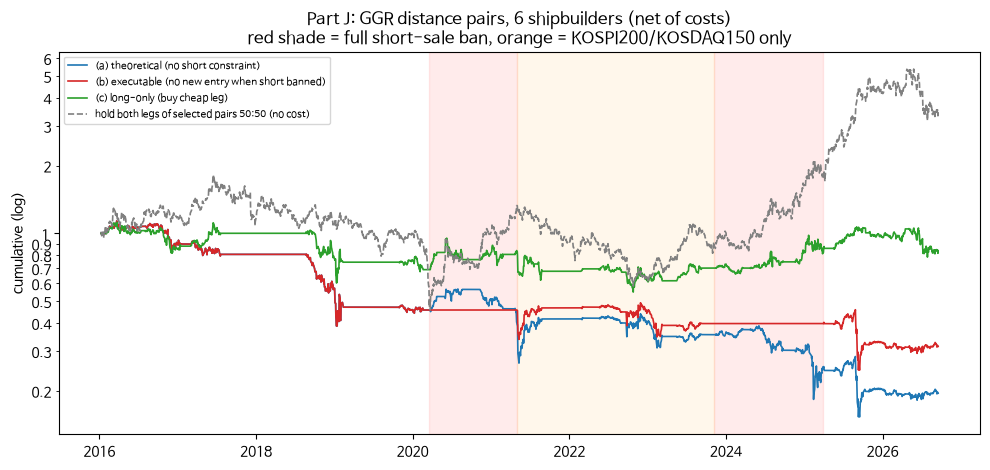

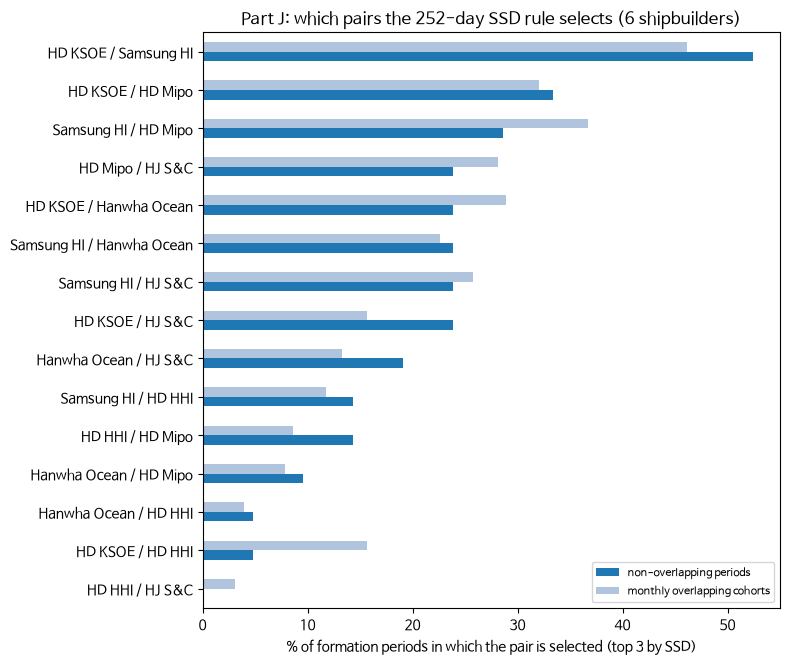

In [9]:
# ---- J-6. 그림: 누적 수익(본 분석) + 페어 선택 빈도 ----
fig, ax = plt.subplots(figsize=(10, 4.8))
labs = {"a": "(a) theoretical (no short constraint)", "b": "(b) executable (no new entry when short banned)",
        "c": "(c) long-only (buy cheap leg)", "bench": "hold both legs of selected pairs 50:50 (no cost)"}
sty = {"a": ("tab:blue", "-"), "b": ("tab:red", "-"), "c": ("tab:green", "-"), "bench": ("grey", "--")}
for v in ["a", "b", "c", "bench"]:
    ax.plot((1 + R_non[v]).cumprod(), color=sty[v][0], ls=sty[v][1], lw=1.2, label=labs[v])
for a_, b_ in BAN_FULL:
    ax.axvspan(pd.Timestamp(a_), pd.Timestamp(b_), color="red", alpha=0.08)
ax.axvspan(pd.Timestamp(PARTIAL[0]), pd.Timestamp(PARTIAL[1]), color="orange", alpha=0.08)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}")); ax.yaxis.set_minor_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
ax.set_ylabel("cumulative (log)")
ax.set_title("Part J: GGR distance pairs, 6 shipbuilders (net of costs)\nred shade = full short-sale ban, orange = KOSPI200/KOSDAQ150 only")
ax.legend(fontsize=7, loc="upper left")
plt.tight_layout(); plt.savefig(f"{RES_DIR}/fig_J1_cumulative.png", bbox_inches="tight"); plt.show()

sel_non = pd.Series([f"{ENJ[a]} / {ENJ[b]}" for c in CH_non for a, b in c["pairs"]]).value_counts()
sel_ovl = pd.Series([f"{ENJ[a]} / {ENJ[b]}" for c in RUN["ovl"][1] for a, b in c["pairs"]]).value_counts()
sel = pd.DataFrame({"non-overlapping periods": sel_non / len(CH_non) * 100,
                    "monthly overlapping cohorts": sel_ovl / len(RUN["ovl"][1]) * 100}).fillna(0).sort_values("non-overlapping periods")
fig, ax = plt.subplots(figsize=(8, 0.35 * len(sel) + 1.5))
sel.plot.barh(ax=ax, color=["tab:blue", "lightsteelblue"])
ax.set_xlabel("% of formation periods in which the pair is selected (top 3 by SSD)")
ax.set_title("Part J: which pairs the 252-day SSD rule selects (6 shipbuilders)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(f"{RES_DIR}/fig_J2_pair_selection.png", bbox_inches="tight"); plt.show()